# <b> Credit Scoring & Probability of Default (PD)

Proyek ini bertujuan untuk membangun model machine learning prediktif dalam menilai risiko gagal bayar (default risk) calon nasabah unbanked dan underserved pada Home Credit. Masalah utama yang dihadapi adalah tiadanya riwayat kredit formal pada populasi ini serta tingginya ketimpangan kelas target (class imbalance ~8,07% default). Untuk mengatasinya, proyek ini memanfaatkan alternative data berbasis skema relational (ERD) yang mengagregasikan riwayat transaksi eksternal dan internal (bureau, previous_application, installments, dsb.) ke tingkat nasabah (SK_ID_CURR).

## <b> 1. Setup, Konfigurasi & Deteksi GPU

In [4]:
import os, gc, json, subprocess, warnings
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score, brier_score_loss)
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from scipy import stats as scipy_stats
from IPython.display import display
import shap

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 150)

SEED = 42
N_FOLDS = 5
np.random.seed(SEED)

# Dataset path
INPUT_DIR = "/kaggle/input/competitions/home-credit-default-risk"
OUTPUT_DIR = "/kaggle/working"

In [5]:
# Check GPU availability
try:
    gpu_info = subprocess.check_output(
        ["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv,noheader"],
        stderr=subprocess.DEVNULL
    ).decode().strip()
    USE_GPU = True
    print("GPU terdeteksi:", USE_GPU)
    print(gpu_info)
except Exception:
    USE_GPU = False
    print("GPU terdeteksi:", USE_GPU)
    print("Tidak ada GPU terdeteksi -> semua model otomatis fallback ke CPU.")

print("Input dir :", INPUT_DIR)
print("Output dir:", OUTPUT_DIR)

GPU terdeteksi: True
Tesla T4, 15360 MiB
Tesla T4, 15360 MiB
Input dir : /kaggle/input/competitions/home-credit-default-risk
Output dir: /kaggle/working


In [6]:
def read_csv(name):
    return pd.read_csv(os.path.join(INPUT_DIR, name))

app_train      = read_csv("application_train.csv")
app_test       = read_csv("application_test.csv")
bureau         = read_csv("bureau.csv")
bureau_balance = read_csv("bureau_balance.csv")
prev_app       = read_csv("previous_application.csv")
pos_cash       = read_csv("POS_CASH_balance.csv")
installments   = read_csv("installments_payments.csv")
credit_card    = read_csv("credit_card_balance.csv")

for name, df in [("app_train", app_train), ("app_test", app_test), ("bureau", bureau),
                  ("bureau_balance", bureau_balance), ("previous_application", prev_app),
                  ("POS_CASH_balance", pos_cash), ("installments_payments", installments),
                  ("credit_card_balance", credit_card)]:
    print(f"{name:22s}: {df.shape}")

app_train["TARGET"].value_counts(normalize=True).rename("share")

app_train             : (307511, 122)
app_test              : (48744, 121)
bureau                : (1716428, 17)
bureau_balance        : (27299925, 3)
previous_application  : (1670214, 37)
POS_CASH_balance      : (10001358, 8)
installments_payments : (13605401, 8)
credit_card_balance   : (3840312, 23)


TARGET
0    0.919271
1    0.080729
Name: share, dtype: float64

![image.png](Entity-Relational-Diagram.png)

Struktur dataset ini menggunakan skema relasional yang berpusat pada tabel application_train (307.511 baris) dan application_test (48.744 baris) sebagai data utama pengajuan kredit. Tabel utama tersebut terhubung ke berbagai tabel pendukung melalui kunci unik (SK_ID_CURR, SK_ID_BUREAU, dan SK_ID_PREV). Tabel pendukung mencakup riwayat kredit luar di Credit Bureau (bureau dan bureau_balance), riwayat pengajuan internal sebelumnya (previous_application), serta catatan detail pembayaran dan saldo bulanan nasabah (POS_CASH_balance, installments_payments, dan credit_card_balance).

Pada tabel utama, variabel target mengalami ketidakseimbangan kelas (class imbalance) yang cukup ekstrem. Sebagian besar nasabah tercatat mampu melunasi pinjaman atau Kelas 0 (91,93%), sementara nasabah yang mengalami masalah pembayaran atau Kelas 1 hanya mencakup 8,07% dari keseluruhan data.

Pemrosesan ERD dilakukan secara bertingkat (bottom-up). Tabel historis transaksi di-agregasi terlebih dahulu ke tabel induknya (SK_ID_BUREAU dan SK_ID_PREV), lalu dirangkum ke tingkat nasabah (SK_ID_CURR). Dataset train dan test diproses lewat pipeline agregasi yang identik secara terpisah tanpa pernah menggabungkan baris keduanya, lalu kolom hasil encoding disamakan (align) agar struktur fitur antara train dan test konsisten sebelum tahap pemodelan.

## <b> 2. Exploratory Data Analysis

### Missing Values Overview

Jumlah kolom dengan missing value: 67 dari 122 kolom


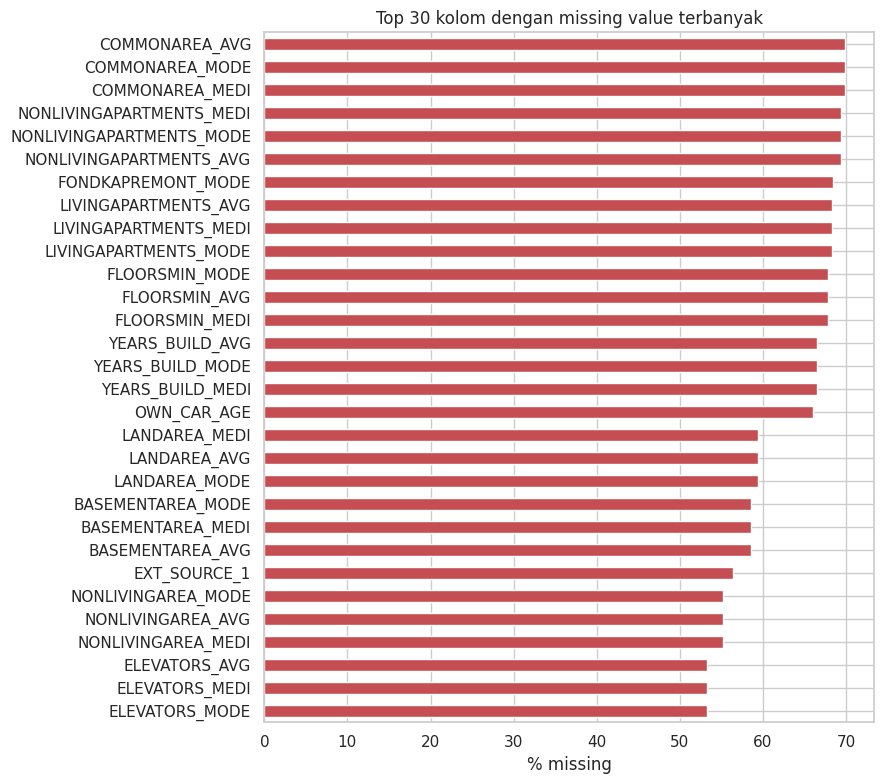

,pct_missing
COMMONAREA_AVG,69.872297
COMMONAREA_MODE,69.872297
COMMONAREA_MEDI,69.872297
NONLIVINGAPARTMENTS_MEDI,69.432963
NONLIVINGAPARTMENTS_MODE,69.432963
NONLIVINGAPARTMENTS_AVG,69.432963
FONDKAPREMONT_MODE,68.386172
LIVINGAPARTMENTS_AVG,68.354953
LIVINGAPARTMENTS_MEDI,68.354953
LIVINGAPARTMENTS_MODE,68.354953


In [7]:
missing = app_train.isnull().mean().sort_values(ascending=False) * 100
missing = missing[missing > 0]
print(f"Jumlah kolom dengan missing value: {len(missing)} dari {app_train.shape[1]} kolom")

plt.figure(figsize=(9, 8))
missing.head(30).plot(kind="barh", color="#C44E52")
plt.gca().invert_yaxis()
plt.xlabel("% missing")
plt.title("Top 30 kolom dengan missing value terbanyak")
plt.tight_layout(); plt.show()

missing.head(15).to_frame("pct_missing")

Hasil identifikasi menunjukkan terdapat 67 dari 122 kolom yang memiliki missing values. Sebagian besar fitur dengan persentase nilai hilang tertinggi (mencapai ~69,8%) berasal dari kelompok variabel properti/hunian (seperti COMMONAREA_*, NONLIVINGAPARTMENTS_*, dan LIVINGAPARTMENTS_*).

Kolom dengan tingkat missingness ekstrem tidak langsung dihapus (drop), melainkan dievaluasi nilainya. Ketiadaan data pada variabel properti dan apartment bisa saja menandakan bahwa nasabah memang tidak memiliki apartment/properti tersebut (Missing Not at Random/MNAR), sehingga ketiadaan data itu sendiri menyimpan sinyal informasi prediktif. Untuk menanganinya nilai missing diisi dengan kategori baru seperti 'XNA' atau 'Missing' agar model berbasis pohon (tree-based models) dapat menangkap pola ketiadaan informasi tersebut secara eksplisit.

### Target Imbalance

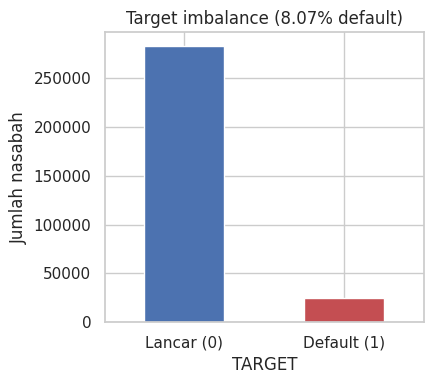

TARGET
0    0.919271
1    0.080729
Name: share, dtype: float64

In [8]:
plt.figure(figsize=(4.5, 4))
app_train["TARGET"].value_counts().plot(kind="bar", color=["#4C72B0", "#C44E52"])
plt.title(f"Target imbalance ({app_train['TARGET'].mean()*100:.2f}% default)")
plt.xticks([0, 1], ["Lancar (0)", "Default (1)"], rotation=0)
plt.ylabel("Jumlah nasabah")
plt.tight_layout(); plt.show()

app_train["TARGET"].value_counts(normalize=True).rename("share")

dalam dataset terdapat ketimpangan kelas (class imbalance) yang cukup ekstrem pada variabel TARGET. Mayoritas nasabah tergolong mampu melunasi pinjaman (Kelas 0 / Lancar mencakup 91,93% atau ~282.686 nasabah), sedangkan nasabah yang mengalami kendala pembayaran (Kelas 1 / Default) hanya porsinya 8,07% (~24.825 nasabah). artinya jika model memprediksi seluruh nasabah sebagai "Lancar" (Kelas 0), model secara naif akan langsung mendapatkan akurasi sebesar 91,93%. Namun, model tersebut gagal total dalam mendeteksi nasabah berniat default, yang berisiko menimbulkan kerugian finansial langsung bagi lembaga keuangan.

nantinya masalah class imbalance ini tidak ditangani dengan resampling (SMOTE/undersampling) maupun class weighting, melainkan dengan tiga strategi yang lebih sesuai untuk tujuan Probability of Default (PD):

1. Pemilihan evaluation metric yang tahan terhadap imbalance — ROC-AUC dan KS Statistic untuk mengukur daya pemisahan (ranking) kelas mayoritas vs minoritas pada seluruh threshold, dilengkapi PR-AUC yang lebih sensitif terhadap kelas minoritas, tanpa terpengaruh dominasi akurasi kelas mayoritas.
2. Stratified K-Fold cross validation, sehingga proporsi 8,07% default terjaga sama di setiap fold dan estimasi performa tidak bias.
3. Menjaga kalibrasi probabilitas — karena output yang dibutuhkan adalah PD (probabilitas riil), bukan label keras. Class weighting justru cenderung merusak kalibrasi (mendorong probabilitas menjauh dari base rate), sehingga sengaja tidak dipakai. Keandalan probabilitas nantinya diverifikasi lewat calibration curve dan Brier score.

### Numerical Feature Analysis

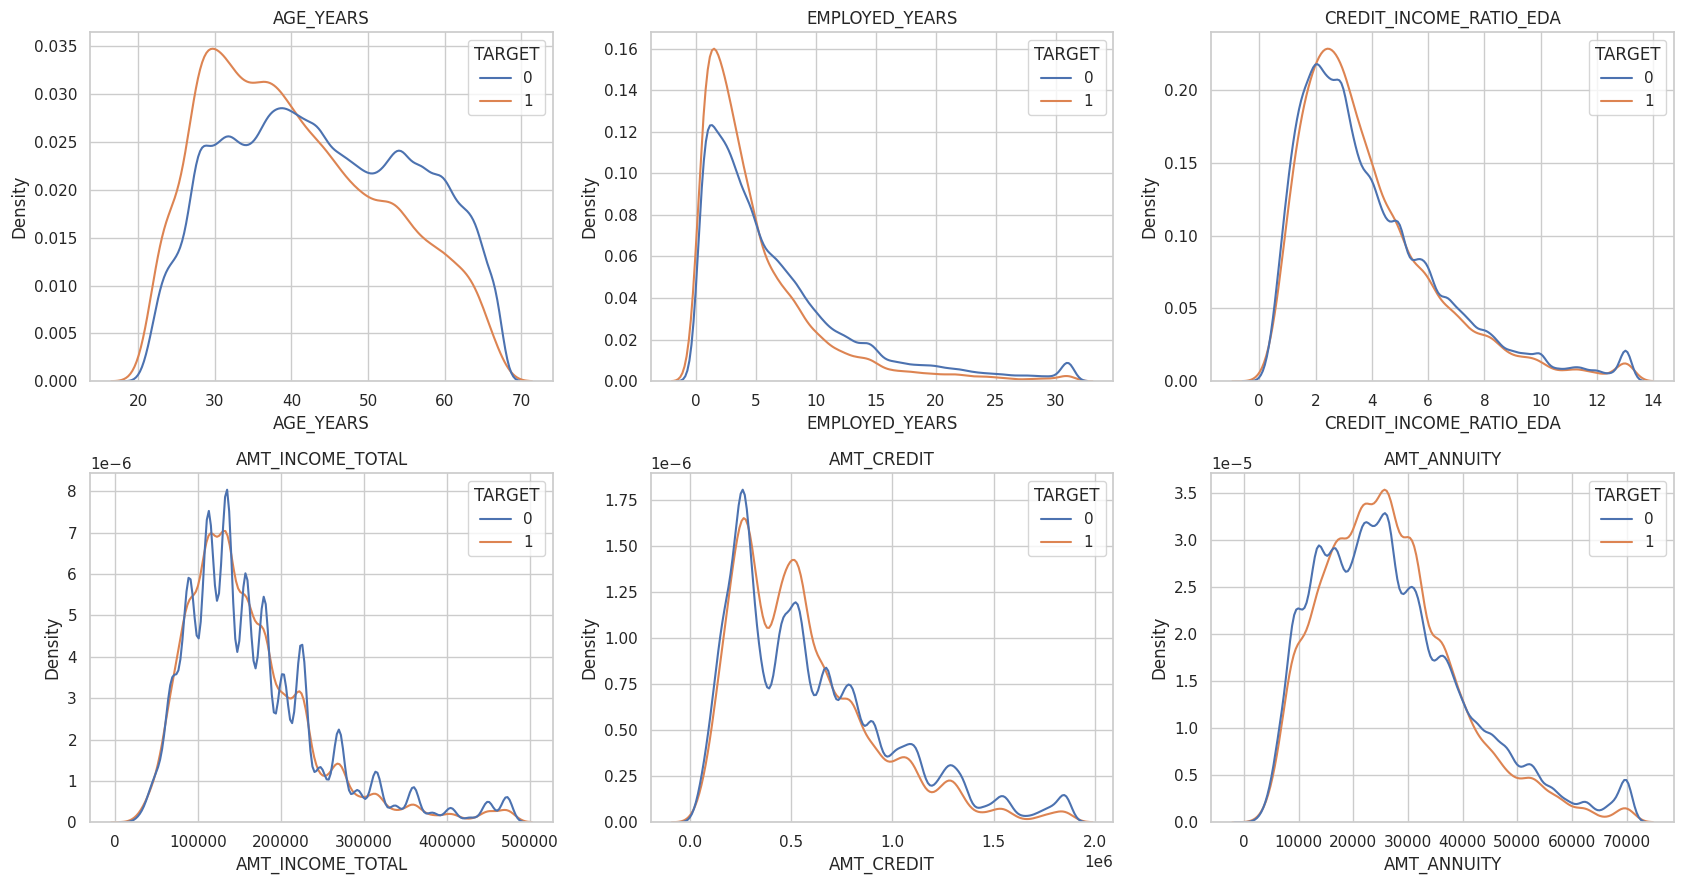

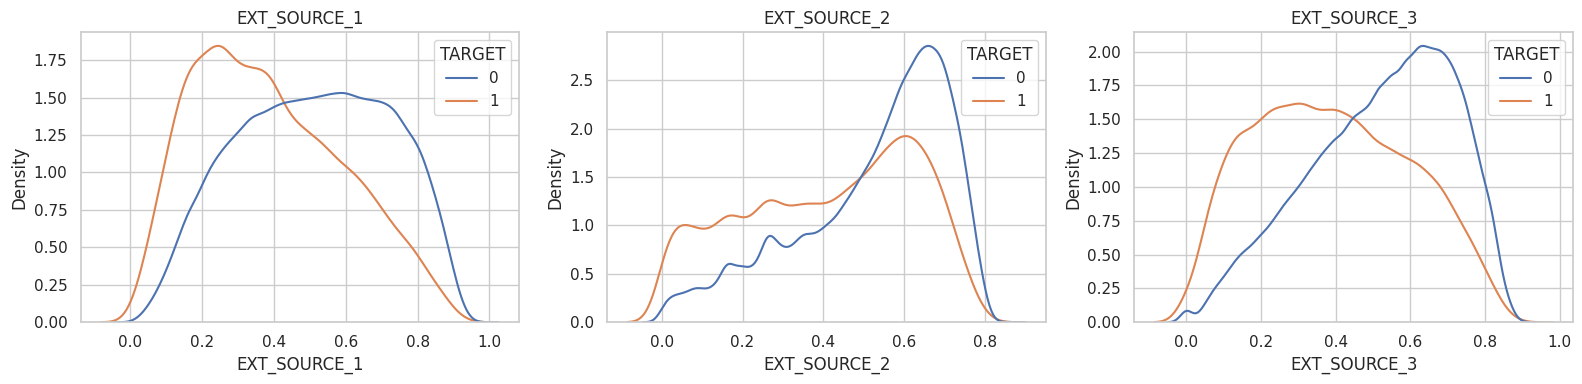

In [9]:
app_train["AGE_YEARS"]     = -app_train["DAYS_BIRTH"] / 365.25
app_train["EMPLOYED_YEARS"] = (-app_train["DAYS_EMPLOYED"].replace(365243, np.nan)) / 365.25
app_train["CREDIT_INCOME_RATIO_EDA"] = app_train["AMT_CREDIT"] / app_train["AMT_INCOME_TOTAL"]

num_features_eda = ["AGE_YEARS", "EMPLOYED_YEARS", "CREDIT_INCOME_RATIO_EDA",
                     "AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY"]

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for ax, col in zip(axes.flatten(), num_features_eda):
    data = app_train[[col, "TARGET"]].copy()
    clip_upper = data[col].quantile(0.99)
    data[col] = data[col].clip(upper=clip_upper)
    sns.kdeplot(data=data, x=col, hue="TARGET", ax=ax, common_norm=False)
    ax.set_title(col)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]):
    sns.kdeplot(data=app_train, x=col, hue="TARGET", ax=ax, common_norm=False)
    ax.set_title(col)
plt.tight_layout(); plt.show()

Variable skor eksternal (EXT_SOURCE_1, 2, 3) serta faktor demografi/stabilitas (DAYS_BIRTH dan DAYS_EMPLOYED) menunjukkan daya pemisah (separability) paling jelas. Nasabah berusia muda, bermasa kerja singkat (< 5 tahun), atau memiliki skor eksternal rendah terbukti mendominasi kelompok berisiko tinggi (TARGET = 1). semetara pada variabel pendapatan (AMT_INCOME_TOTAL), besaran pinjaman (AMT_CREDIT), dan angsuran (AMT_ANNUITY) memiliki kurva distribusi dengan pergerakan yang identik di antara kedua kelompok target.

In [10]:
sig_test_features = num_features_eda + ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
rows = []
for col in sig_test_features:
    good = app_train.loc[app_train["TARGET"] == 0, col].dropna()
    bad  = app_train.loc[app_train["TARGET"] == 1, col].dropna()
    if len(good) < 30 or len(bad) < 30:
        continue
    stat, p_value = scipy_stats.mannwhitneyu(good, bad, alternative="two-sided")
    # Rank-biserial correlation: r = 1 - 2U/(n1*n2), effect size utk Mann-Whitney
    n1, n2 = len(good), len(bad)
    rank_biserial = 1 - (2 * stat) / (n1 * n2)
    abs_r = abs(rank_biserial)
    effect_label = "Kecil" if abs_r < 0.1 else ("Sedang" if abs_r < 0.3 else "Besar")
    rows.append({
        "feature": col,
        "median_lancar": good.median(),
        "median_default": bad.median(),
        "mannwhitney_p_value": p_value,
        "signifikan_(p<0.05)": p_value < 0.05,
        "rank_biserial_r": rank_biserial,
        "effect_size": effect_label,
    })

sig_df_numeric = pd.DataFrame(rows).sort_values("rank_biserial_r", key=lambda s: s.abs(), ascending=False)
sig_df_numeric

,feature,median_lancar,median_default,mannwhitney_p_value,signifikan_(p<0.05),rank_biserial_r,effect_size
8,EXT_SOURCE_3,0.546023,0.379100,0.000000e+00,True,-0.358800,Besar
6,EXT_SOURCE_1,0.517452,0.361675,0.000000e+00,True,-0.331362,Besar
7,EXT_SOURCE_2,0.573905,0.440381,0.000000e+00,True,-0.312240,Besar
0,AGE_YEARS,43.468857,39.101985,0.000000e+00,True,-0.166005,Sedang
1,EMPLOYED_YEARS,4.629706,3.367556,0.000000e+00,True,-0.164782,Sedang
3,AMT_INCOME_TOTAL,148500.000000,135000.000000,1.024920e-23,True,-0.038277,Kecil
4,AMT_CREDIT,517788.000000,497520.000000,2.360189e-22,True,-0.037165,Kecil
2,CREDIT_INCOME_RATIO_EDA,3.266653,3.253143,3.187524e-01,False,-0.003810,Kecil
5,AMT_ANNUITY,24876.000000,25263.000000,9.675618e-01,False,-0.000155,Kecil


Hasil statistik mengonfirmasi secara kuat bahwa EXT_SOURCE_3 ($r = -0,358$), EXT_SOURCE_1 ($r = -0,331$), dan EXT_SOURCE_2 ($r = -0,312$) memiliki effect size kategori "Besar" ($\vert{}r\vert{} \ge 0,3$). Sementara pada Fitur demografi AGE_YEARS ($r = -0,166$) dan EMPLOYED_YEARS ($r = -0,165$) terbukti valid memiliki effect size kategori "Sedang" ($0,1 \le \vert{}r\vert{} < 0,3$). ini memvalidasi visualisasi KDE plot sebelumnya: nasabah berisiko (default) secara signifikan memiliki median skor eksternal lebih rendah, usia lebih muda (~39 vs ~43 tahun), dan masa kerja lebih singkat (~3,3 vs ~4,6 tahun).

Variabel AMT_INCOME_TOTAL dan AMT_CREDIT memiliki nilai effect size rendah ($r \approx -0,038$, kategori "Kecil") dan pada variabel CREDIT_INCOME_RATIO_EDA dan AMT_ANNUITY bahkan terbukti tidak signifikan secara statistik ($p$-value $> 0,05$). artinya variabel nominal tersebut secara mandiri memang tidak memiliki daya pisah yang berarti terhadap risiko default.

### Categorical variable analysis

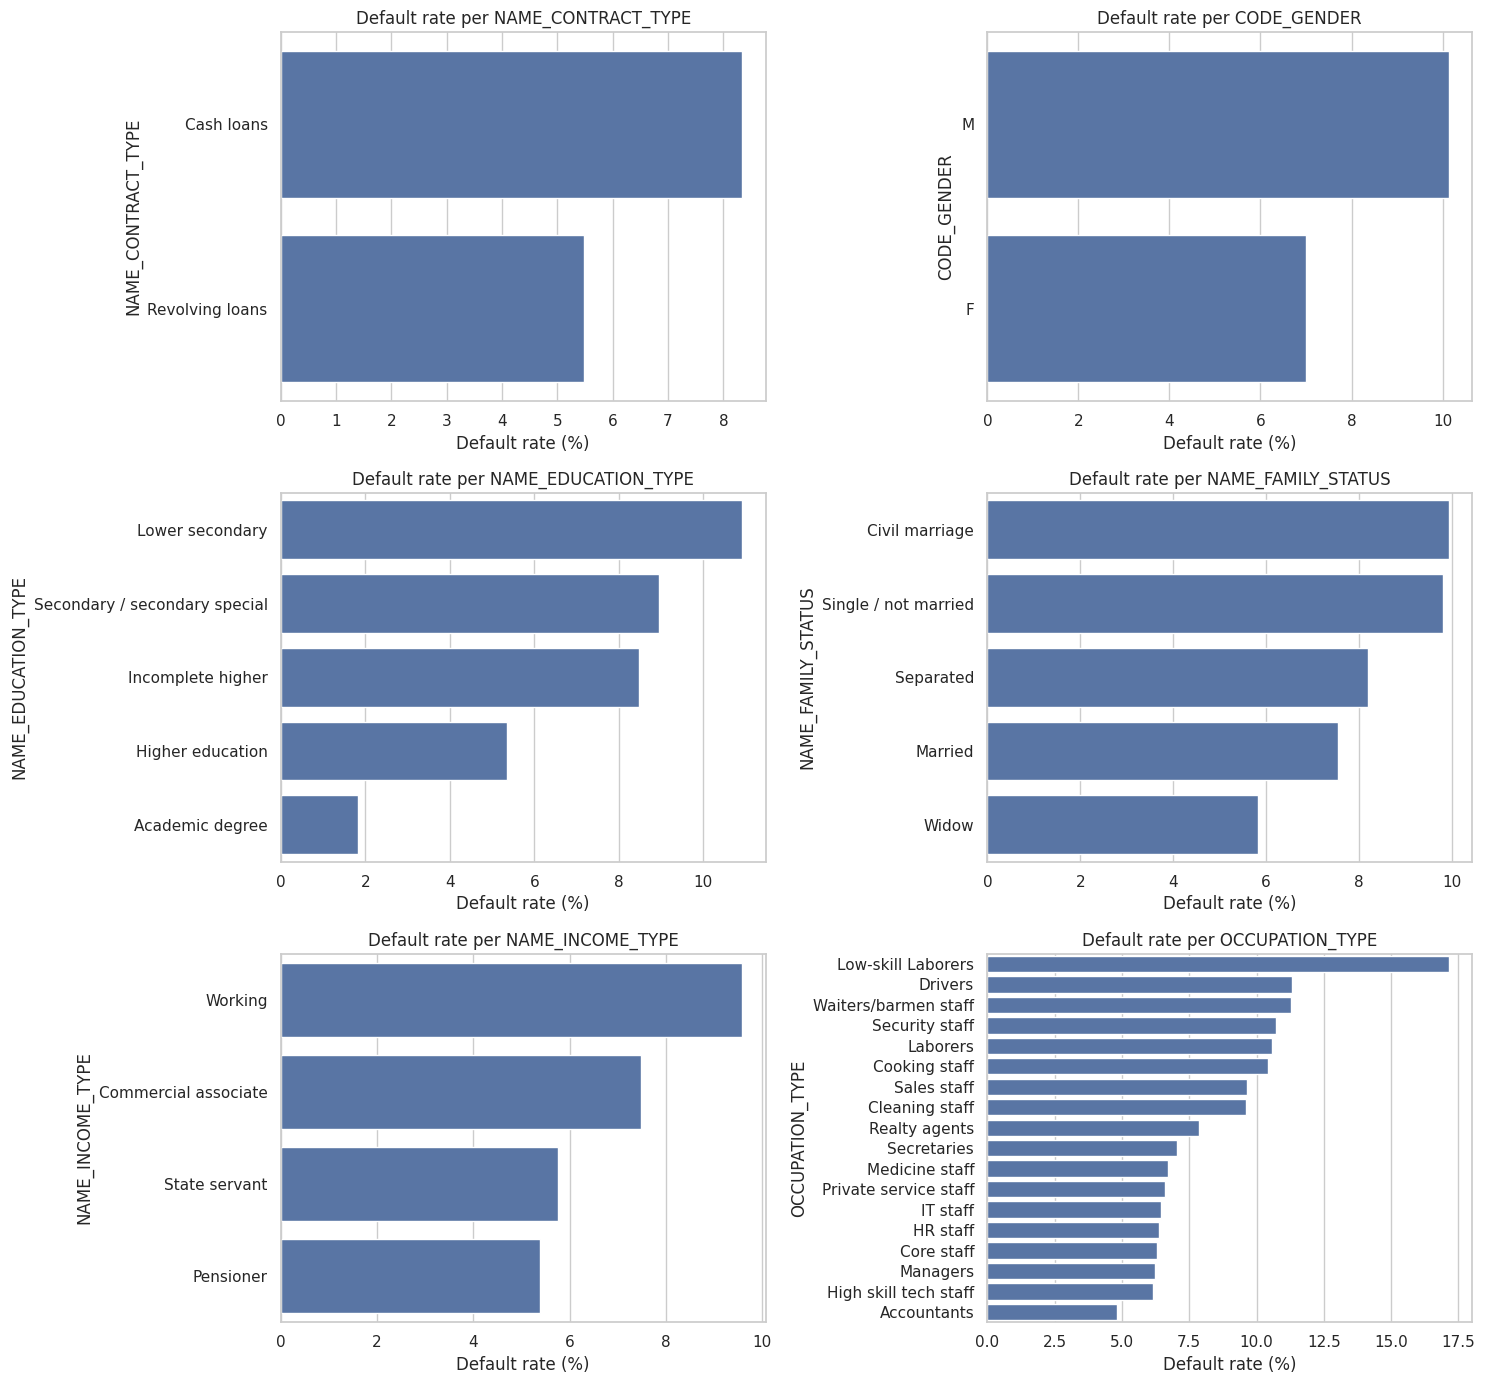

In [11]:
cat_features_eda = ["NAME_CONTRACT_TYPE", "CODE_GENDER", "NAME_EDUCATION_TYPE",
                    "NAME_FAMILY_STATUS", "NAME_INCOME_TYPE", "OCCUPATION_TYPE"]

fig, axes = plt.subplots(3, 2, figsize=(15, 14))
for ax, col in zip(axes.flatten(), cat_features_eda):
    rate = app_train.groupby(col)["TARGET"].agg(["mean", "count"]).sort_values("mean", ascending=False)
    rate = rate[rate["count"] >= 50]  # buang kategori dengan sampel terlalu sedikit (noisy)
    sns.barplot(x=rate["mean"] * 100, y=rate.index, ax=ax, color="#4C72B0")
    ax.set_title(f"Default rate per {col}")
    ax.set_xlabel("Default rate (%)")
plt.tight_layout(); plt.show()

Profil dengan tingkat default tertinggi ditemukan pada nasabah laki-laki (CODE_GENDER: M ~10%), pengaju pinjaman tunai (NAME_CONTRACT_TYPE: Cash loans ~8,3%), berpendidikan rendah (NAME_EDUCATION_TYPE: Lower secondary ~11%), berstatus belum menikah atau civil marriage (NAME_FAMILY_STATUS ~10%), serta memiliki sumber pendapatan kerja umum (NAME_INCOME_TYPE: Working ~9,5%). Berdasarkan jenis pekerjaan (OCCUPATION_TYPE), kelompok pekerja kerah biru dan lapangan seperti Low-skill Laborers (>17%), Drivers (~11%), dan Waiters/barmen staff (~11%) mencatatkan risiko gagal bayar paling dominan. sementara tingkat risiko terendah secara konsisten ditunjukkan oleh nasabah berpendidikan tinggi (Academic degree <2%), pensiunan (Pensioner) atau ASN (State servant) (~5–5,5%), serta pekerja profesional seperti Accountants (<5%) dan High skill tech staff.

In [12]:
rows = []
for col in cat_features_eda:
    contingency = pd.crosstab(app_train[col], app_train["TARGET"])
    chi2, p_value, dof, _ = scipy_stats.chi2_contingency(contingency)
    n = contingency.sum().sum()
    r, k = contingency.shape
    cramers_v = np.sqrt((chi2 / n) / (min(r - 1, k - 1)))
    effect_label = "Lemah" if cramers_v < 0.1 else ("Sedang" if cramers_v < 0.3 else "Kuat")
    rows.append({
        "feature": col,
        "n_kategori": contingency.shape[0],
        "chi2_statistic": chi2,
        "chi2_p_value": p_value,
        "signifikan_(p<0.05)": p_value < 0.05,
        "cramers_v": cramers_v,
        "effect_size": effect_label,
    })

sig_df_categorical = pd.DataFrame(rows).sort_values("cramers_v", ascending=False)
sig_df_categorical

,feature,n_kategori,chi2_statistic,chi2_p_value,signifikan_(p<0.05),cramers_v,effect_size
5,OCCUPATION_TYPE,18,1402.846796,3.784500e-288,True,0.081516,Lemah
4,NAME_INCOME_TYPE,8,1253.470808,1.928146e-266,True,0.063845,Lemah
2,NAME_EDUCATION_TYPE,5,1019.213187,2.447681e-219,True,0.057571,Lemah
1,CODE_GENDER,3,920.791334,1.129022e-200,True,0.054721,Lemah
3,NAME_FAMILY_STATUS,6,504.694083,7.744842e-107,True,0.040512,Lemah
0,NAME_CONTRACT_TYPE,2,293.150542,1.023515e-65,True,0.030876,Lemah


Pengujian statistik Chi-Square dan indikator Cramer's V mengonfirmasi secara kuantitatif bahwa seluruh fitur kategorikal utama terbukti signifikan secara statistik ($p < 0,05$) berhubungan dengan variabel target, dengan kekuatan hubungan (effect size) kategori "Lemah" ($V < 0,1$). tetapi walaupun secara statistik hubungannya tergolong lemah jika berdiri sendiri, perbedaan risiko antar-kelompok ini bukan sekadar kebetulan acak. 

Dari temuan ini bisa dimanfaatkan secara optimal oleh algoritma berbasis tree (seperti LightGBM, XGBoost, atau CatBoost) karena model tree-based bekerja dengan cara menggabungkan interaksi non-linier antar-fitur kategorikal. Interaksi dari berbagai sinyal lemah ini akan menciptakan segmen nasabah spesifik dengan akumulasi risiko default yang jauh lebih tinggi dan presisi dibanding jika dievaluasi secara terpisah.

### Correlation Heatmap

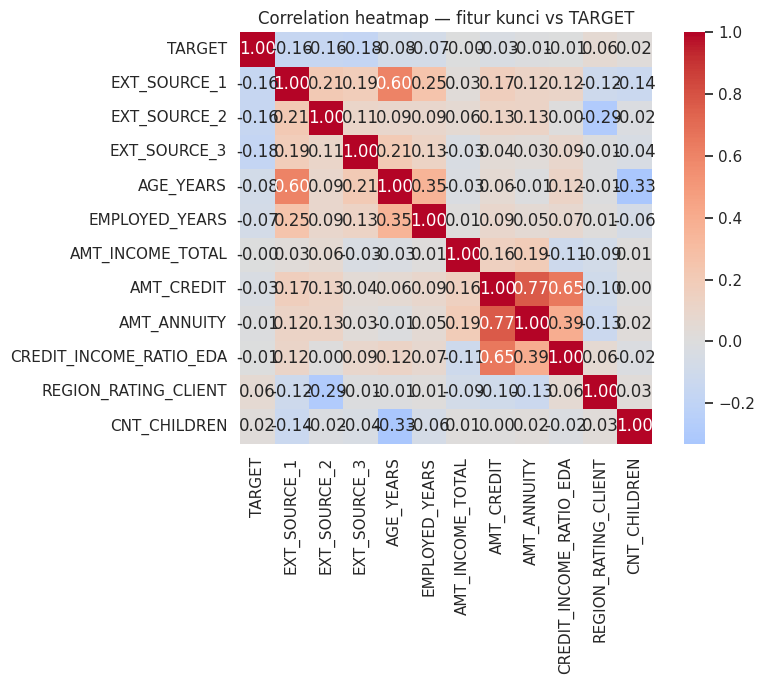

,feature,pearson_r,p_value,signifikan_(p<0.05)
2,EXT_SOURCE_3,-0.178919,0.000000e+00,True
1,EXT_SOURCE_2,-0.160472,0.000000e+00,True
0,EXT_SOURCE_1,-0.155317,0.000000e+00,True
3,AGE_YEARS,-0.078239,0.000000e+00,True
4,EMPLOYED_YEARS,-0.074958,6.736931e-311,True
9,REGION_RATING_CLIENT,0.058899,2.172433e-234,True
6,AMT_CREDIT,-0.030369,1.147460e-63,True
10,CNT_CHILDREN,0.019187,1.922492e-26,True
7,AMT_ANNUITY,-0.012817,1.182677e-12,True
8,CREDIT_INCOME_RATIO_EDA,-0.007727,1.828711e-05,True


In [13]:
corr_cols = ["TARGET", "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3", "AGE_YEARS",
             "EMPLOYED_YEARS", "AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY",
             "CREDIT_INCOME_RATIO_EDA", "REGION_RATING_CLIENT", "CNT_CHILDREN"]

corr_matrix = app_train[corr_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation heatmap — fitur kunci vs TARGET")
plt.tight_layout(); plt.show()

# Korelasi Pearson + p-value terhadap TARGET, untuk memvalidasi bahwa korelasi bukan kebetulan
rows = []
for col in corr_cols:
    if col == "TARGET":
        continue
    valid = app_train[[col, "TARGET"]].dropna()
    r, p_value = scipy_stats.pearsonr(valid[col], valid["TARGET"])
    rows.append({"feature": col, "pearson_r": r, "p_value": p_value, "signifikan_(p<0.05)": p_value < 0.05})

pd.DataFrame(rows).sort_values("pearson_r", key=lambda s: s.abs(), ascending=False)

 nilai korelasi linier tunggal terhadap target variable tergolong lemah hingga moderat ($\vert{}r\vert{} < 0,2$) kemudian selain itu ditemukan juga beberapa fitur financial yang multicolinearity. dengan kondisi dataset seperti ini untuk mencegah multicolinearity akan lebih baik menggunakan algoritma berbasis tree (LightGBM/XGBoost/CatBoost) yang robust terhadap multikolinearitas serta mampu menangkap pola hubungan non-linier.

### Outlier Detection

In [14]:
anomaly_flag = app_train["DAYS_EMPLOYED"] == 365243
print(f"Jumlah baris dengan DAYS_EMPLOYED anomali (365243): {anomaly_flag.sum()} "
      f"({anomaly_flag.mean()*100:.2f}% dari data)")
print(f"Default rate pada baris anomali   : {app_train.loc[anomaly_flag, 'TARGET'].mean()*100:.2f}%")
print(f"Default rate pada baris non-anomali: {app_train.loc[~anomaly_flag, 'TARGET'].mean()*100:.2f}%")

# AMT_INCOME_TOTAL: cek outlier ekstrem
income_99 = app_train["AMT_INCOME_TOTAL"].quantile(0.99)
print(f"\n99th percentile AMT_INCOME_TOTAL: {income_99:,.0f}")
print(f"Jumlah baris di atas itu: {(app_train['AMT_INCOME_TOTAL'] > income_99).sum()}")

app_train.drop(columns=["CREDIT_INCOME_RATIO_EDA"], inplace=True)

Jumlah baris dengan DAYS_EMPLOYED anomali (365243): 55374 (18.01% dari data)
Default rate pada baris anomali   : 5.40%
Default rate pada baris non-anomali: 8.66%

99th percentile AMT_INCOME_TOTAL: 472,500
Jumlah baris di atas itu: 3014


Pada variable DAYS_EMPLOYED, anomali terdeteksi lewat nilai ekstrim persis 365.243 hari (setara 1.000 tahun), yang mencakup 55.374 baris (18,01% dari data). Nilai ini merupakan placeholder code bawaan sistem untuk menandakan kelompok pensiunan atau pengangguran. Nilai ini dipertahankan karena menyimpan sinyal prediktif terkait segmen berisiko rendah dan dapat diproses secara native oleh algoritma tree-based (seperti LightGBM/CatBoost) tanpa merusak pembagian percabangan (split decision).

Pengecekan persentil ke-99 (income $\ge 472.500$) mengidentifikasi 3.014 baris dengan pendapatan sangat tinggi (right-skewed). Data outlier ini dibiarkan (keep) tanpa proses trimming atau transformasi, karena algoritma tree-based (LightGBM/CatBoost) yang digunakan bersifat robust dan tidak terpengaruh oleh skala nilai ekstrem.

### Missingness sebagai Sinyal 

In [15]:
has_bureau_record = app_train["SK_ID_CURR"].isin(bureau["SK_ID_CURR"])

contingency_bureau = pd.crosstab(has_bureau_record, app_train["TARGET"])
chi2_b, p_value_b, _, _ = scipy_stats.chi2_contingency(contingency_bureau)
n_b = contingency_bureau.sum().sum()
cramers_v_b = np.sqrt((chi2_b / n_b) / min(contingency_bureau.shape[0] - 1, contingency_bureau.shape[1] - 1))

pd.DataFrame({
    "punya_riwayat_bureau": [True, False],
    "n_nasabah": [has_bureau_record.sum(), (~has_bureau_record).sum()],
    "default_rate": [app_train.loc[has_bureau_record, "TARGET"].mean(),
                      app_train.loc[~has_bureau_record, "TARGET"].mean()],
}).assign(chi2_p_value=p_value_b, cramers_v=cramers_v_b)

,punya_riwayat_bureau,n_nasabah,default_rate,chi2_p_value,cramers_v
0,True,263491,0.077301,2.740698e-65,0.030772
1,False,44020,0.101249,2.740698e-65,0.030772


menguji apakah ketiadaan data di Credit Bureau (bureau) menyimpan sinyal prediktif (Missing Not at Random). Pengujian dilakukan dengan membuat indikator boolean has_bureau_record, lalu mengevaluasi default rate serta mengujinya lewat Uji Chi-Square dan Cramer's V.

Uji Chi-Square menunjukkan perbedaan default rate yang signifikan secara statistik ($p < 0{,}001$) antara nasabah tanpa riwayat bureau (10,12%) dan dengan riwayat (7,73%). Meskipun perbedaan relatifnya mencapai ~31%, nilai Cramer's V yang sangat kecil menunjukkan kekuatan asosiasi tunggal yang lemah. Oleh karena itu, indikator has_bureau_record ini sebaiknya tidak berdiri sendiri, melainkan dimanfaatkan sebagai fitur pendukung (MNAR signal) dalam tree based model.

## <b> 3. Feature Engineering

### Feature Engineering from application table

In [16]:
def add_application_features(df):
    df = df.copy()
    df["DAYS_EMPLOYED"].replace(365243, np.nan, inplace=True)

    df["CREDIT_INCOME_RATIO"]   = df["AMT_CREDIT"] / df["AMT_INCOME_TOTAL"]
    df["ANNUITY_INCOME_RATIO"]  = df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"]
    df["CREDIT_ANNUITY_RATIO"]  = df["AMT_CREDIT"] / df["AMT_ANNUITY"]
    df["CREDIT_GOODS_RATIO"]    = df["AMT_CREDIT"] / df["AMT_GOODS_PRICE"]
    df["INCOME_PER_PERSON"]     = df["AMT_INCOME_TOTAL"] / df["CNT_FAM_MEMBERS"]
    df["ANNUITY_PER_PERSON"]    = df["AMT_ANNUITY"] / df["CNT_FAM_MEMBERS"]

    df["AGE_YEARS"]            = -df["DAYS_BIRTH"] / 365.25
    df["EMPLOYED_YEARS"]       = -df["DAYS_EMPLOYED"] / 365.25
    df["EMPLOYED_AGE_RATIO"]   = df["EMPLOYED_YEARS"] / df["AGE_YEARS"]
    df["ID_PUBLISH_AGE_RATIO"] = (-df["DAYS_ID_PUBLISH"] / 365.25) / df["AGE_YEARS"]

    ext_cols = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
    df["EXT_SOURCE_MEAN"] = df[ext_cols].mean(axis=1)
    df["EXT_SOURCE_STD"]  = df[ext_cols].std(axis=1)
    df["EXT_SOURCE_MIN"]  = df[ext_cols].min(axis=1)
    df["EXT_SOURCE_MAX"]  = df[ext_cols].max(axis=1)
    df["EXT_SOURCE_1_2"]  = df["EXT_SOURCE_1"] * df["EXT_SOURCE_2"]
    df["EXT_SOURCE_2_3"]  = df["EXT_SOURCE_2"] * df["EXT_SOURCE_3"]

    doc_cols = [c for c in df.columns if c.startswith("FLAG_DOCUMENT_")]
    df["DOCUMENT_COUNT"]  = df[doc_cols].sum(axis=1)
    contact_cols = ["FLAG_MOBIL", "FLAG_EMP_PHONE", "FLAG_WORK_PHONE",
                     "FLAG_CONT_MOBILE", "FLAG_PHONE", "FLAG_EMAIL"]
    df["CONTACT_COUNT"]   = df[contact_cols].sum(axis=1)
    df["REGION_RATING_MEAN"] = df[["REGION_RATING_CLIENT", "REGION_RATING_CLIENT_W_CITY"]].mean(axis=1)
    return df

app_train = add_application_features(app_train)
app_test  = add_application_features(app_test)
app_train.filter(like="RATIO").describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
DAYS_REGISTRATION,307511.0,-4986.120328,3522.886321,-24672.000000,-7479.500000,-4504.000000,-2010.000000,0.000000
CREDIT_INCOME_RATIO,307511.0,3.957570,2.689728,0.004808,2.018667,3.265067,5.159880,84.736842
ANNUITY_INCOME_RATIO,307499.0,0.180930,0.094574,0.000224,0.114782,0.162833,0.229067,1.875965
CREDIT_ANNUITY_RATIO,307499.0,21.612322,7.823823,8.036674,15.614496,20.000000,27.099985,45.305079
CREDIT_GOODS_RATIO,307233.0,1.122995,0.124045,0.150000,1.000000,1.118800,1.198000,6.000000
EMPLOYED_AGE_RATIO,252137.0,0.156861,0.133549,-0.000000,0.056099,0.118733,0.219170,0.728811
ID_PUBLISH_AGE_RATIO,307511.0,0.193693,0.101416,0.000000,0.117138,0.191463,0.279762,0.469001


feature engineering ini dilakukan dengan tujuan mengekstrak informasi domain finansial, stabilitas demografi, agregasi skor eksternal, dan kelengkapan dokumen/kontak nasabah dari tabel utama (application_train/test) dengan fungsi meningkatkan daya pemisah (separability) model. feature engineering yang dilakukan secara garis besar adalah dengan melakukan penambahan financial ratio, Transformasi fitur usia (tetapi dengan convert DAYS_EMPLOYED pada pensiunan menjadi nan agar tidak menghasilkan angka yang tidak valid) dan juga mengekstrak statistik dari external source karena tidak ada informasi jelas pada deskripsi dataset ext_source sebenarnya variable apa

### feature engineering on bureau and bureau_balance profile 

In [17]:
bureau_balance["STATUS_DPD"] = bureau_balance["STATUS"].map(
    {"C": 0, "0": 0, "1": 1, "2": 2, "3": 3, "4": 4, "5": 5})

bb_agg = bureau_balance.groupby("SK_ID_BUREAU").agg(
    BB_MONTHS_COUNT=("MONTHS_BALANCE", "count"),
    BB_MAX_DPD=("STATUS_DPD", "max"),
    BB_MEAN_DPD=("STATUS_DPD", "mean"),
    BB_EVER_LATE=("STATUS_DPD", lambda s: (s > 0).any().astype(int)),
).reset_index()

bureau = bureau.merge(bb_agg, on="SK_ID_BUREAU", how="left")
bureau["CREDIT_ACTIVE_ACTIVE"] = (bureau["CREDIT_ACTIVE"] == "Active").astype(int)
bureau["CREDIT_OVERDUE_FLAG"]  = (bureau["AMT_CREDIT_SUM_OVERDUE"] > 0).astype(int)
bureau["DEBT_CREDIT_RATIO"]    = bureau["AMT_CREDIT_SUM_DEBT"] / bureau["AMT_CREDIT_SUM"].replace(0, np.nan)

bureau_agg = bureau.groupby("SK_ID_CURR").agg(
    BUREAU_COUNT=("SK_ID_BUREAU", "count"),
    BUREAU_ACTIVE_COUNT=("CREDIT_ACTIVE_ACTIVE", "sum"),
    BUREAU_ACTIVE_RATIO=("CREDIT_ACTIVE_ACTIVE", "mean"),
    BUREAU_OVERDUE_COUNT=("CREDIT_OVERDUE_FLAG", "sum"),
    BUREAU_MAX_OVERDUE_AMT=("AMT_CREDIT_MAX_OVERDUE", "max"),
    BUREAU_DEBT_SUM=("AMT_CREDIT_SUM_DEBT", "sum"),
    BUREAU_CREDIT_SUM=("AMT_CREDIT_SUM", "sum"),
    BUREAU_DEBT_CREDIT_RATIO_MEAN=("DEBT_CREDIT_RATIO", "mean"),
    BUREAU_MAX_DPD=("BB_MAX_DPD", "max"),
    BUREAU_MEAN_DPD=("BB_MEAN_DPD", "mean"),
    BUREAU_EVER_LATE_RATIO=("BB_EVER_LATE", "mean"),
    BUREAU_DAYS_CREDIT_MIN=("DAYS_CREDIT", "min"),
    BUREAU_DAYS_CREDIT_MAX=("DAYS_CREDIT", "max"),
).reset_index()

del bureau_balance, bb_agg; gc.collect()
print("bureau_agg:", bureau_agg.shape)

bureau_agg: (305811, 14)


Feature engineering ini menggabungkan tabel relasional bureau dan bureau_balance untuk mengompres riwayat kredit luar nasabah (one-to-many) menjadi 13 fitur komposit di level nasabah, feature yang dibentuk diproses ini mencakup profil tunggakan seperti rata rata durasi keterlambatan bayar dan maksimumnya, profil pinjaman yang masih aktif seperti persentase kredit yang masih aktif, total akumulasi hutang dan jarak waktu antar pinjaman. feature feature ini dibuat agar model bisa dapat informasi yang lebih diskriminatif untuk memisahkan mana yang default dan tidak

### feature engineering on previous application

In [18]:
prev_app["APP_CREDIT_RATIO"] = prev_app["AMT_APPLICATION"] / prev_app["AMT_CREDIT"].replace(0, np.nan)
prev_app["WAS_REFUSED"]     = (prev_app["NAME_CONTRACT_STATUS"] == "Refused").astype(int)
prev_app["WAS_APPROVED"]    = (prev_app["NAME_CONTRACT_STATUS"] == "Approved").astype(int)

prev_agg = prev_app.groupby("SK_ID_CURR").agg(
    PREV_COUNT=("SK_ID_PREV", "count"),
    PREV_REFUSED_RATIO=("WAS_REFUSED", "mean"),
    PREV_APPROVED_RATIO=("WAS_APPROVED", "mean"),
    PREV_AMT_APPLICATION_MEAN=("AMT_APPLICATION", "mean"),
    PREV_AMT_CREDIT_MEAN=("AMT_CREDIT", "mean"),
    PREV_APP_CREDIT_RATIO_MEAN=("APP_CREDIT_RATIO", "mean"),
    PREV_DAYS_DECISION_MEAN=("DAYS_DECISION", "mean"),
    PREV_CNT_PAYMENT_MEAN=("CNT_PAYMENT", "mean"),
).reset_index()
print("prev_agg:", prev_agg.shape)

prev_agg: (338857, 9)


yang dilakukan adalah mengompres riwayat pengajuan kredit internal nasabah (one-to-many) menjadi 8 fitur agregasi di level nasabah. Fitur yang dibentuk mencakup rasio persetujuan dan penolakan (PREV_APPROVED_RATIO, PREV_REFUSED_RATIO), rasio serta rata-rata nominal pengajuan vs persetujuan (PREV_APP_CREDIT_RATIO_MEAN, PREV_AMT_APPLICATION_MEAN, PREV_AMT_CREDIT_MEAN), serta statistik volume, rata-rata tenor, dan kebaruan pengajuan (PREV_COUNT, PREV_CNT_PAYMENT_MEAN, PREV_DAYS_DECISION_MEAN)

### feature engineering on monthly history (POS_CASH_BALANCE)

In [19]:
pos_cash["POS_LATE_FLAG"] = (pos_cash["SK_DPD"] > 0).astype(int)
pos_agg = pos_cash.groupby("SK_ID_CURR").agg(
    POS_COUNT=("SK_ID_PREV", "count"),
    POS_MEAN_INSTALMENT=("CNT_INSTALMENT", "mean"),
    POS_MAX_DPD=("SK_DPD", "max"),
    POS_MEAN_DPD=("SK_DPD", "mean"),
    POS_LATE_RATIO=("POS_LATE_FLAG", "mean"),
    POS_MEAN_DPD_DEF=("SK_DPD_DEF", "mean"),
).reset_index()
print("pos_agg:", pos_agg.shape)

pos_agg: (337252, 7)


konversi data table riwayat cicilan bulanan untuk pinjaman Point of Sale dan Cash Loans (one-to-many) menjadi 6 fitur agregasi di level nasabah (SK_ID_CURR). Fitur yang dibentuk mencakup total catatan bulanan (POS_COUNT), rata-rata jumlah cicilan (POS_MEAN_INSTALMENT), nilai maksimum dan rata-rata keterlambatan bayar (POS_MAX_DPD, POS_MEAN_DPD), proporsi bulan terlambat bayar (POS_LATE_RATIO), serta rata-rata keterlambatan khusus untuk pinjaman yang mengalami perubahan syarat kredit (POS_MEAN_DPD_DEF). dibuat agar model mendapatkan informasi tentang kepatuhan terhadap kontrak kredit yang diambil nasabah

### feature engineering on installment payments

In [20]:
installments["DAYS_LATE"]      = (installments["DAYS_ENTRY_PAYMENT"] - installments["DAYS_INSTALMENT"]).clip(lower=0)
installments["AMT_PAY_RATIO"]  = installments["AMT_PAYMENT"] / installments["AMT_INSTALMENT"].replace(0, np.nan)
installments["UNDERPAID_FLAG"] = (installments["AMT_PAYMENT"] < installments["AMT_INSTALMENT"]).astype(int)
installments["LATE_FLAG"]      = (installments["DAYS_LATE"] > 0).astype(int)

instal_agg = installments.groupby("SK_ID_CURR").agg(
    INSTAL_COUNT=("SK_ID_PREV", "count"),
    INSTAL_LATE_RATIO=("LATE_FLAG", "mean"),
    INSTAL_MAX_DAYS_LATE=("DAYS_LATE", "max"),
    INSTAL_MEAN_DAYS_LATE=("DAYS_LATE", "mean"),
    INSTAL_UNDERPAID_RATIO=("UNDERPAID_FLAG", "mean"),
    INSTAL_PAY_RATIO_MEAN=("AMT_PAY_RATIO", "mean"),
    INSTAL_PAY_RATIO_MIN=("AMT_PAY_RATIO", "min"),
    INSTAL_AMT_INSTALMENT_SUM=("AMT_INSTALMENT", "sum"),
    INSTAL_AMT_PAYMENT_SUM=("AMT_PAYMENT", "sum"),
).reset_index()
print("instal_agg:", instal_agg.shape)

instal_agg: (339587, 10)


konversi riwayat pembayaran cicilan nyata nasabah (one-to-many) menjadi 9 fitur agregasi di level SK_ID_CURR. Fitur yang dibentuk mencakup rasio dan durasi keterlambatan bayar (INSTAL_LATE_RATIO, INSTAL_MAX_DAYS_LATE, INSTAL_MEAN_DAYS_LATE), proporsi pembayaran kurang (INSTAL_UNDERPAID_RATIO), statistik rasio kelengkapan bayar (INSTAL_PAY_RATIO_MEAN, INSTAL_PAY_RATIO_MIN), serta total akumulasi tagihan dan realisasi pembayaran (INSTAL_AMT_INSTALMENT_SUM, INSTAL_AMT_PAYMENT_SUM, INSTAL_COUNT).

### Feature engineering on credit card balance

In [21]:
credit_card["CC_UTILIZATION"]     = credit_card["AMT_BALANCE"] / credit_card["AMT_CREDIT_LIMIT_ACTUAL"].replace(0, np.nan)
credit_card["CC_OVER_LIMIT_FLAG"] = (credit_card["CC_UTILIZATION"] > 1).astype(int)
credit_card["CC_LATE_FLAG"]       = (credit_card["SK_DPD"] > 0).astype(int)

cc_agg = credit_card.groupby("SK_ID_CURR").agg(
    CC_COUNT=("SK_ID_PREV", "count"),
    CC_MEAN_BALANCE=("AMT_BALANCE", "mean"),
    CC_MEAN_UTILIZATION=("CC_UTILIZATION", "mean"),
    CC_MAX_UTILIZATION=("CC_UTILIZATION", "max"),
    CC_OVER_LIMIT_RATIO=("CC_OVER_LIMIT_FLAG", "mean"),
    CC_LATE_RATIO=("CC_LATE_FLAG", "mean"),
    CC_MEAN_DRAWINGS=("AMT_DRAWINGS_CURRENT", "mean"),
    CC_MIN_PAYMENT_RATIO=("AMT_INST_MIN_REGULARITY", "mean"),
).reset_index()
print("cc_agg:", cc_agg.shape)

del bureau, prev_app, pos_cash, installments, credit_card
gc.collect()

cc_agg: (103558, 9)


0

yang dilakukan adalah mengkonversi riwayat penggunaan kartu kredit bulanan nasabah (one-to-many) menjadi 8 fitur agregasi di level SK_ID_CURR. Fitur yang dibentuk mencakup rasio penggunaan limit (CC_UTILIZATION = AMT_BALANCE / AMT_CREDIT_LIMIT_ACTUAL), statistik rata-rata dan maksimum utilization (CC_MEAN_UTILIZATION, CC_MAX_UTILIZATION), rasio frekuensi melampaui limit (CC_OVER_LIMIT_RATIO), rasio keterlambatan bayar (CC_LATE_RATIO), serta rata-rata penarikan tunai/transaksi (CC_MEAN_DRAWINGS) dan kewajiban minimum bayar (CC_MIN_PAYMENT_RATIO)

kemudian karena keseluruhan table pada ERD datanya sudah di extract melalui aggregasi berdasarkan level per nasabah, yang dilakukan selanjutnya adalah delete variable dataframe mentah karena selanjutnya akan menggunakan data hasil ringkasan per nasabah untuk mengklasifikasikan apakah nasabah default atau tidak

## <b> 4. Merge and do Data prep

### Merge Table 

In [22]:
def merge_all(df):
    df = df.merge(bureau_agg, on="SK_ID_CURR", how="left")
    df = df.merge(prev_agg,   on="SK_ID_CURR", how="left")
    df = df.merge(pos_agg,    on="SK_ID_CURR", how="left")
    df = df.merge(instal_agg, on="SK_ID_CURR", how="left")
    df = df.merge(cc_agg,     on="SK_ID_CURR", how="left")
    return df

train = merge_all(app_train)
test  = merge_all(app_test)
print("train:", train.shape, "| test:", test.shape)

train: (307511, 185) | test: (48744, 184)


Fungsi merge_all menggabungkan seluruh fitur agregasi relasional (bureau_agg, prev_agg, pos_agg, instal_agg, cc_agg) ke tabel utama berbasis SK_ID_CURR menggunakan left join. Proses ini dieksekusi secara terpisah pada app_train dan app_test untuk mencegah data leakage sekaligus mempertahankan jumlah baris asli nasabah (307.511 train vs 48.744 test), dengan selisih 1 kolom akibat keberadaan label TARGET pada train

In [23]:
del app_train, app_test, bureau_agg, prev_agg, pos_agg, instal_agg, cc_agg
gc.collect()

0

In [24]:
df.head()

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,AMT_PAYMENT_CURRENT,AMT_PAYMENT_TOTAL_CURRENT,AMT_RECEIVABLE_PRINCIPAL,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF,CC_UTILIZATION,CC_OVER_LIMIT_FLAG,CC_LATE_FLAG
0,2562384,378907,-6,56.970,135000,0.0,877.5,0.0,877.5,1700.325,1800.0,1800.0,0.000,0.000,0.000,0.0,1,0.0,1.0,35.0,Active,0,0,0.000422,0,0
1,2582071,363914,-1,63975.555,45000,2250.0,2250.0,0.0,0.0,2250.000,2250.0,2250.0,60175.080,64875.555,64875.555,1.0,1,0.0,0.0,69.0,Active,0,0,1.421679,1,0
2,1740877,371185,-7,31815.225,450000,0.0,0.0,0.0,0.0,2250.000,2250.0,2250.0,26926.425,31460.085,31460.085,0.0,0,0.0,0.0,30.0,Active,0,0,0.070700,0,0
3,1389973,337855,-4,236572.110,225000,2250.0,2250.0,0.0,0.0,11795.760,11925.0,11925.0,224949.285,233048.970,233048.970,1.0,1,0.0,0.0,10.0,Active,0,0,1.051432,1,0
4,1891521,126868,-1,453919.455,450000,0.0,11547.0,0.0,11547.0,22924.890,27000.0,27000.0,443044.395,453919.455,453919.455,0.0,1,0.0,1.0,101.0,Active,0,0,1.008710,1,0


sekarang dataset telah di simplifikasi menjadi per nasabah dan menggunakan aggregate valuenya, nantinya model akan dilatih menggunakan dataset ini dan bukan menggunakan variable variable mentah yang ada pada relational database karena variabel mentah pada tabel relasional memiliki struktur one-to-many dan jumlah baris yang bervariasi per nasabah, sehingga harus diolah menjadi matriks 2D berformat satu baris per nasabah

### Categorical Encoding

In [25]:
to_drop = ["CODE_GENDER"]
train_gender_raw = train["CODE_GENDER"].copy() if "CODE_GENDER" in train.columns else None

train = train.drop(columns=[c for c in to_drop if c in train.columns])
test  = test.drop(columns=[c for c in to_drop if c in test.columns])

cat_cols = train.select_dtypes(include="object").columns.tolist()
print(f"{len(cat_cols)} kolom kategorikal ikut di-encode sebagai fitur model "
      f"(di luar {to_drop}, sudah dikeluarkan dari fitur model)")

# encoder di fit ke train, fit_transform ke test
for col in cat_cols:
    if train[col].nunique(dropna=False) <= 2:
        le = LabelEncoder()
        le.fit(train[col].astype(str))
        train[col] = le.transform(train[col].astype(str))

        test_str = test[col].astype(str)
        known_mask = test_str.isin(le.classes_)
        test[col] = 0  
        test.loc[known_mask, col] = le.transform(test_str[known_mask])
    else:
        dummies_train = pd.get_dummies(train[col], prefix=col, dummy_na=True)
        dummies_test = pd.get_dummies(test[col], prefix=col, dummy_na=True)
        dummies_test = dummies_test.reindex(columns=dummies_train.columns, fill_value=0)

        train = pd.concat([train.drop(columns=[col]), dummies_train], axis=1)
        test = pd.concat([test.drop(columns=[col]), dummies_test], axis=1)

print("Final train:", train.shape, "| test:", test.shape)
num_cols_train = train.select_dtypes(include=[np.number]).columns
num_cols_test = test.select_dtypes(include=[np.number]).columns
train[num_cols_train] = train[num_cols_train].replace([np.inf, -np.inf], np.nan)
test[num_cols_test] = test[num_cols_test].replace([np.inf, -np.inf], np.nan)

feature_cols = [c for c in train.columns if c not in ["TARGET", "SK_ID_CURR"]]
X, y, X_test = train[feature_cols], train["TARGET"], test[feature_cols]
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

15 kolom kategorikal ikut di-encode sebagai fitur model (di luar ['CODE_GENDER'], sudah dikeluarkan dari fitur model)
Final train: (307511, 315) | test: (48744, 314)


Kolom CODE_GENDER dihapus dari fitur pemodelan untuk mencegah bias diskriminatif (fairness) dalam
penilaian risiko kredit berbasis jenis kelamin, sekaligus mengeklusi variabel sensitif/demografis
yang tidak relevan secara finansial agar keputusan model murni didasarkan pada kapasitas dan
perilaku keuangan nasabah.

### Sanity Check Setelah proses Merge

In [26]:
agg_feature_prefixes = ("BUREAU_", "PREV_", "POS_", "INSTAL_", "CC_")
agg_features = [c for c in feature_cols if c.startswith(agg_feature_prefixes)]
print(f"Jumlah fitur hasil agregasi dari tabel satelit: {len(agg_features)}")

# Coverage: berapa % nasabah yang punya data di tiap tabel satelit (bukan NaN semua)
coverage = {}
for prefix, label in [("BUREAU_", "bureau"), ("PREV_", "previous_application"),
                       ("POS_", "POS_CASH"), ("INSTAL_", "installments"), ("CC_", "credit_card")]:
    cols = [c for c in agg_features if c.startswith(prefix)]
    if cols:
        coverage[label] = train[cols].notna().any(axis=1).mean() * 100

pd.Series(coverage).rename("pct_nasabah_punya_data").to_frame()

Jumlah fitur hasil agregasi dari tabel satelit: 44


,pct_nasabah_punya_data
bureau,85.685065
previous_application,94.649297
POS_CASH,94.124763
installments,94.839859
credit_card,28.260778


dilakukan untuk mengukur sejauh mana data nasabah di tabel utama terhubung dengan tabel-tabel satelit setelah proses. Hasilnya menunjukkan coverage yang tinggi pada table previous_application (94,65%), installments (94,84%), POS_CASH (94,12%), dan bureau (85,69%), yang menandakan mayoritas nasabah memiliki riwayat historis yang banyak. Sementara itu, tabel credit_card hanya memiliki coverage sebesar 28,26%, memvalidasi bahwa hanya sebagian kecil nasabah yang memiliki atau menggunakan fasilitas kartu kredit.

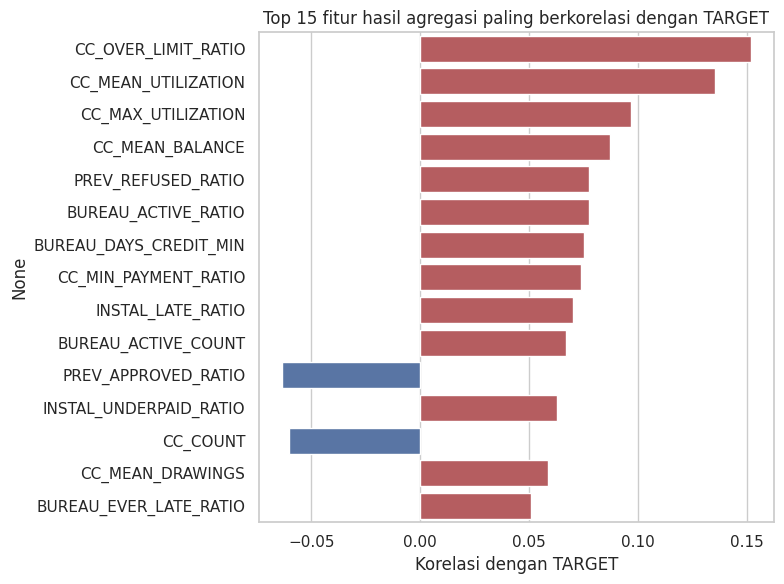

CC_OVER_LIMIT_RATIO       0.151700
CC_MEAN_UTILIZATION       0.135560
CC_MAX_UTILIZATION        0.097011
CC_MEAN_BALANCE           0.087177
PREV_REFUSED_RATIO        0.077671
BUREAU_ACTIVE_RATIO       0.077356
BUREAU_DAYS_CREDIT_MIN    0.075248
CC_MIN_PAYMENT_RATIO      0.073724
INSTAL_LATE_RATIO         0.070015
BUREAU_ACTIVE_COUNT       0.067128
PREV_APPROVED_RATIO      -0.063521
INSTAL_UNDERPAID_RATIO    0.062612
CC_COUNT                 -0.060481
CC_MEAN_DRAWINGS          0.058732
BUREAU_EVER_LATE_RATIO    0.050821
Name: TARGET, dtype: float64

In [27]:
# Korelasi fitur agregasi dengan TARGET, diurutkan berdasarkan kekuatan hubungan
agg_corr = train[agg_features + ["TARGET"]].corr()["TARGET"].drop("TARGET")
top_agg_corr = agg_corr.reindex(agg_corr.abs().sort_values(ascending=False).index).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(x=top_agg_corr.values, y=top_agg_corr.index,
            palette=["#C44E52" if v > 0 else "#4C72B0" for v in top_agg_corr.values])
plt.title("Top 15 fitur hasil agregasi paling berkorelasi dengan TARGET")
plt.xlabel("Korelasi dengan TARGET")
plt.tight_layout(); plt.show()

top_agg_corr

korelasi positif tertinggi terhadap risiko gagal bayar (TARGET) didominasi oleh indikator perilaku Credit Card—khususnya CC_OVER_LIMIT_RATIO (0.152) dan CC_MEAN_UTILIZATION (0.136), hasil ini menunjukkan bahwa tingginya tingkat penggunaan limit serta over-limit kartu kredit berbanding lurus dengan peningkatan risiko gagal bayar.

Sebaliknya pada fitur seperti PREV_APPROVED_RATIO (-0.064) dan CC_COUNT (-0.060) memiliki korelasi negatif, mengindikasikan bahwa riwayat persetujuan pinjaman sebelumnya dan tingginya jumlah kepemilikan kartu kredit cenderung mencerminkan profil nasabah yang lebih terpercaya.

### Feature Selection using IV and WoE

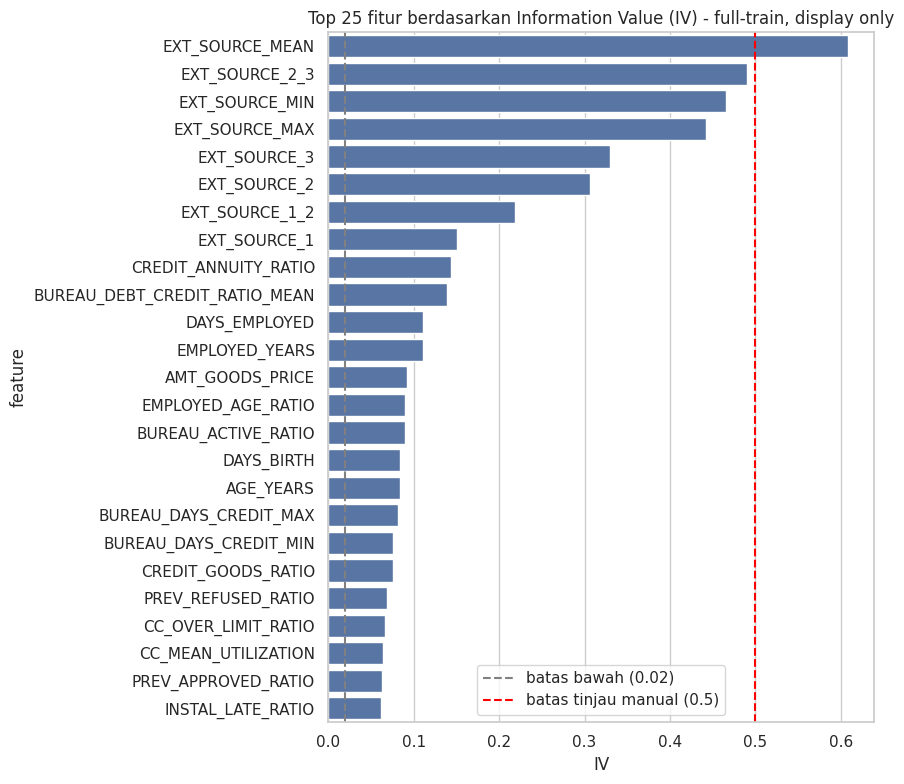

kategori
Tidak prediktif                212
Lemah                           89
Sedang                           6
Kuat                             5
Sangat kuat (tinjau manual)      1
Name: count, dtype: int64


,feature,IV,kategori
117,EXT_SOURCE_MEAN,0.608308,Sangat kuat (tinjau manual)
122,EXT_SOURCE_2_3,0.489527,Kuat
119,EXT_SOURCE_MIN,0.466012,Kuat
120,EXT_SOURCE_MAX,0.442383,Kuat
32,EXT_SOURCE_3,0.329443,Kuat
31,EXT_SOURCE_2,0.306473,Kuat
121,EXT_SOURCE_1_2,0.219147,Sedang
30,EXT_SOURCE_1,0.150934,Sedang
111,CREDIT_ANNUITY_RATIO,0.143747,Sedang
133,BUREAU_DEBT_CREDIT_RATIO_MEAN,0.138569,Sedang


In [28]:
# ----- Fungsi IV reusable (dipakai untuk full-train display DAN per-fold selection) -----
def compute_iv(feat_series, target_series):
    data = pd.DataFrame({"feature": feat_series.values, "target": target_series.values})
    if data["feature"].nunique(dropna=False) > 10 and pd.api.types.is_numeric_dtype(data["feature"]):
        binned = pd.qcut(data["feature"], 10, duplicates="drop")
        data["bin"] = binned.astype(object)
        data.loc[data["feature"].isna(), "bin"] = "missing"
    else:
        data["bin"] = data["feature"].fillna("missing").astype(object)
    grouped = data.groupby("bin", observed=True, dropna=False)["target"].agg(["count", "sum"])
    grouped.columns = ["total", "bad"]
    grouped["good"] = grouped["total"] - grouped["bad"]
    # Laplace smoothing (hindari log 0)
    grouped["bad"] = grouped["bad"].replace(0, 0.05)
    grouped["good"] = grouped["good"].replace(0, 0.05)
    total_bad, total_good = grouped["bad"].sum(), grouped["good"].sum()
    dist_bad = grouped["bad"] / total_bad
    dist_good = grouped["good"] / total_good
    woe = np.log(dist_good / dist_bad)
    return float(((dist_good - dist_bad) * woe).sum())

# ----- IV full-train HANYA untuk display/EDA (BUKAN untuk seleksi fitur) -----
iv_rows = [{"feature": feat, "IV": compute_iv(X[feat], y)} for feat in feature_cols]
iv_df = pd.DataFrame(iv_rows).sort_values("IV", ascending=False)

# Kategori IV (pakai np.select)
conditions = [
    iv_df["IV"] < 0.02,
    iv_df["IV"] < 0.1,
    iv_df["IV"] < 0.3,
    iv_df["IV"] < 0.5
]
choices = ["Tidak prediktif", "Lemah", "Sedang", "Kuat"]
iv_df["kategori"] = np.select(conditions, choices, default="Sangat kuat (tinjau manual)")

# Plotting & Display Output
plt.figure(figsize=(9, 8))
sns.barplot(data=iv_df.head(25), y="feature", x="IV", color="#4C72B0")
plt.axvline(0.02, color="grey", linestyle="--", label="batas bawah (0.02)")
plt.axvline(0.5, color="red", linestyle="--", label="batas tinjau manual (0.5)")
plt.title("Top 25 fitur berdasarkan Information Value (IV) - full-train, display only")
plt.legend()
plt.tight_layout()
plt.show()
print(iv_df["kategori"].value_counts())
iv_df.head(20)

 menggunakan metode Weight of Evidence (WoE) dan Information Value (IV) untuk mengukur daya pemisah (predictive power) dari setiap fitur terhadap risiko gagal bayar. Hasilnya menunjukkan bahwa fitur eksternal EXT_SOURCE_MEAN menjadi pembeda paling dominan (IV = 0,6083 / Sangat Kuat), diikuti oleh turunan agregasi eksternal lainnya (EXT_SOURCE_2_3, EXT_SOURCE_MIN, EXT_SOURCE_MAX) pada rentang IV 0,44-0,48 (Kuat), sementara 210 fitur teridentifikasi tidak prediktif ($IV < 0,02$). Ke depannya, 210 fitur tidak prediktif tersebut dapat langsung dieliminasi (feature selection) untuk memangkas dimensi data

Catatan metodologis: perhitungan IV pada tampilan di atas memakai seluruh data train dan hanya untuk keperluan eksplorasi/visualisasi. Keputusan pembuangan fitur (feature selection) TIDAK memakai angka full-train tersebut, melainkan menghitung ulang IV di dalam setiap training fold Stratified K-Fold, lalu membuang fitur hanya jika terbukti tidak prediktif (IV < 0,02) secara konsisten di seluruh fold. Dengan begitu proses seleksi tidak pernah mengintip label fold validasi, sehingga skor OOF bebas dari selection leakage.

sebagai catatan, IV > 5 pada standar Credit Risk Scorecard menandakan variable tersebut adalah pemisah yang kuat untuk klasifikasi tetapi perlu tinjauan karena potensi terjadi overfit/leakage

In [29]:
APPLY_IV_FILTER = True
IV_WHITELIST = [
    "EXT_SOURCE_MEAN", "EXT_SOURCE_1_2", "EXT_SOURCE_2_3", "EXT_SOURCE_MIN", "EXT_SOURCE_MAX",
    "CREDIT_INCOME_RATIO", "INSTAL_LATE_RATIO", "BUREAU_MAX_DPD", "PREV_REFUSED_RATIO",
]
# CREDIT_ANNUITY_RATIO dibuang karena data drift ekstrem (PSI=1.16, lihat Bagian 6), bukan karena leakage
MANUAL_LEAKAGE_BLACKLIST = ["CREDIT_ANNUITY_RATIO"]

if APPLY_IV_FILTER:
    # Hitung IV HANYA pada training fold tiap split -> tidak pernah melihat label fold validasi.
    # Sebuah fitur dianggap "tidak prediktif" hanya jika IV < 0.02 KONSISTEN di SEMUA fold.
    not_predictive_per_fold = []
    for tr_idx, _ in skf.split(X, y):
        X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
        fold_iv = {feat: compute_iv(X_tr[feat], y_tr) for feat in feature_cols}
        not_predictive_per_fold.append({f for f, v in fold_iv.items() if v < 0.02})

    # Irisan (intersection): dibuang hanya bila tidak prediktif di semua fold
    consistently_not_predictive = set.intersection(*not_predictive_per_fold)

    dropped_low  = [f for f in consistently_not_predictive if f not in IV_WHITELIST]
    dropped_high = [f for f in MANUAL_LEAKAGE_BLACKLIST if f in feature_cols]

    print(f"Fitur tidak prediktif (IV<0.02) konsisten di SEMUA {N_FOLDS} fold: {len(consistently_not_predictive)}")
    print(f"Dibuang karena tidak prediktif (di luar whitelist): {len(dropped_low)}")
    print(f"Dibuang karena leakage/drift manual                : {len(dropped_high)} -> {dropped_high}")

    dropped = set(dropped_low) | set(dropped_high)
    selected_features = [f for f in feature_cols if f not in dropped]
    feature_cols = selected_features
    X = X[feature_cols]
    X_test = X_test[feature_cols]

print(f"\nJumlah fitur final yang masuk ke modeling: {len(feature_cols)}")

Fitur tidak prediktif (IV<0.02) konsisten di SEMUA 5 fold: 210
Dibuang karena tidak prediktif (di luar whitelist): 208
Dibuang karena leakage/drift manual                : 1 -> ['CREDIT_ANNUITY_RATIO']

Jumlah fitur final yang masuk ke modeling: 104


### EXT_SOURCE_MEAN

IV EXT_SOURCE_MEAN: 0.6083079644823612

Korelasi EXT_SOURCE_MEAN dengan komponen penyusunnya:


EXT_SOURCE_MEAN    1.000000
EXT_SOURCE_1       0.741583
EXT_SOURCE_2       0.749328
EXT_SOURCE_3       0.704012
Name: EXT_SOURCE_MEAN, dtype: float64


% missing:
  EXT_SOURCE_MEAN: 0.06%
  EXT_SOURCE_1: 56.38%
  EXT_SOURCE_2: 0.21%
  EXT_SOURCE_3: 19.83%


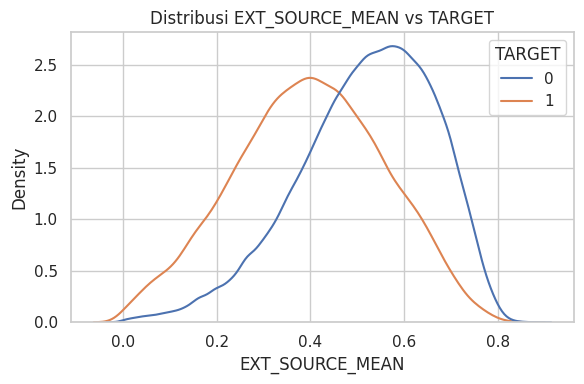


Mann-Whitney p-value: 0.00e+00  |  rank-biserial r: -0.4331


In [30]:
print("IV EXT_SOURCE_MEAN:", iv_df.loc[iv_df["feature"] == "EXT_SOURCE_MEAN", "IV"].values[0])

ext_source_cols = [c for c in ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"] if c in X.columns]

# Korelasi ke komponen penyusun
print("\nKorelasi EXT_SOURCE_MEAN dengan komponen penyusunnya:")
display(X[["EXT_SOURCE_MEAN"] + ext_source_cols].corr()["EXT_SOURCE_MEAN"])

# Pola missingness
print("\n% missing:")
for c in ["EXT_SOURCE_MEAN"] + ext_source_cols:
    print(f"  {c}: {X[c].isna().mean()*100:.2f}%")

# Pemisahan distribusi terhadap TARGET
plt.figure(figsize=(6, 4))
sns.kdeplot(data=pd.DataFrame({"EXT_SOURCE_MEAN": X["EXT_SOURCE_MEAN"], "TARGET": y}),
            x="EXT_SOURCE_MEAN", hue="TARGET", common_norm=False)
plt.title("Distribusi EXT_SOURCE_MEAN vs TARGET")
plt.tight_layout(); plt.show()

# Validasi statistik (Mann-Whitney + effect size) khusus fitur ini
good = X.loc[y == 0, "EXT_SOURCE_MEAN"].dropna()
bad = X.loc[y == 1, "EXT_SOURCE_MEAN"].dropna()
stat, p_value = scipy_stats.mannwhitneyu(good, bad, alternative="two-sided")
rank_biserial = 1 - (2 * stat) / (len(good) * len(bad))
print(f"\nMann-Whitney p-value: {p_value:.2e}  |  rank-biserial r: {rank_biserial:.4f}")

Bukti-bukti statistik di atas (Korelasi, Grafik Distribusi, dan Mann-Whitney $r = -0.4331$) mengonfirmasi secara kuantitatif mengapa IV variabel ini sangat tinggi (0.6083), yaitu karena adanya daya pemisah risikonya yang sangat kuat. Sementara itu, jaminan bahwa variabel ini bebas dari data leakage didasarkan pada logika proses bisnis (temporal alignment), di mana nilai EXT_SOURCE merupakan skor eksternal yang ditarik saat tahap pengajuan aplikasi (aplikasi awal), bukan fitur pasca-pencairan kredit.

## <b> 5. Do Modeling and comparison between model

karena nilai missing value sebelumnya dibuktikan memiliki sifat prediktif (MNAR), bukan missing value secara random maka missing value di feed kedalam model, kemudian juga ada beberapa variable numerik dengan distribusi yang skewed. karena kondisi data yang seperti ini makan model model yang akan dibandingkan adalah tree based model dimana mekanismenya decission split tanpa ada kalkulasi

### Single Decssion Tree Baseline

In [31]:
def quick_ks(y_true, y_score):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    return np.max(np.abs(tpr - fpr))

# 1 estimator LGBM
basic_params = dict(objective="binary", n_estimators=1, max_depth=4, num_leaves=16,
                     random_state=SEED, n_jobs=-1, verbosity=-1)

oof_basic = np.zeros(len(y))
for tr_idx, val_idx in skf.split(X, y):
    basic_model = lgb.LGBMClassifier(**basic_params)
    basic_model.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    oof_basic[val_idx] = basic_model.predict_proba(X.iloc[val_idx])[:, 1]

basic_auc = roc_auc_score(y, oof_basic)
basic_ks = quick_ks(y, oof_basic)
_fpr, _tpr, _thr = roc_curve(y, oof_basic)
basic_threshold = _thr[np.argmax(_tpr - _fpr)]
print(f"Single Decision Tree: AUC={basic_auc:.5f} | KS={basic_ks:.5f} | Threshold optimal={basic_threshold:.4f}")

Single Decision Tree: AUC=0.71831 | KS=0.33198 | Threshold optimal=0.0813


disini single decission treenya menggunakan lgbm yang di set estimatornya = 1, pendekatan ini dilakukan karena DecisionTreeClassifier bawaan scikit-learn bakal error kalau nemu NaN di dataset. Sedangkan LightGBM bisa langsung eksekusi data yang ada NaN-nya

pada model single decission tree punya AUC 0.718 artinya model memiliki probabilitas sebesar 71,83% untuk memberikan skor risiko yang lebih tinggi kepada nasabah yang benar-benar gagal bayar (default) dibandingkan dengan nasabah yang lancar. juga KS nya 0.3320 artinya 

Pada model baseline ini, diperoleh nilai KS Statistic sebesar 0.33198 (33,20%). Artinya pada titik potong persetujuan kredit (cut-off threshold) optimal sebesar 0.0813, bank dapat memisahkan akumulasi populasi nasabah gagal bayar (bad) dan nasabah lancar (good) dengan selisih efisiensi pemisahan maksimum sebesar 33,20%. model berhasil menangkap proporsi nasabah macet dalam jumlah yang jauh lebih dominan dengan hanya mengorbankan 33,20% lebih sedikit nasabah lancar yang salah tereliminasi

### LightGBM 

In [32]:
# Sengaja default params, TANPA early stopping, TANPA hyperparameter tuning, TANPA ensembling --
# merepresentasikan "coba satu model tree-based" sebelum melakukan upaya optimasi serius.
basic_tree_params = dict(objective="binary", n_estimators=100, random_state=SEED, n_jobs=-1, verbosity=-1)

oof_tree = np.zeros(len(y))
for tr_idx, val_idx in skf.split(X, y):
    tree_model = lgb.LGBMClassifier(**basic_tree_params)
    tree_model.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    oof_tree[val_idx] = tree_model.predict_proba(X.iloc[val_idx])[:, 1]

tree_auc = roc_auc_score(y, oof_tree)
tree_ks = quick_ks(y, oof_tree)
_fpr, _tpr, _thr = roc_curve(y, oof_tree)
tree_threshold = _thr[np.argmax(_tpr - _fpr)]
print(f"LightGBM: AUC={tree_auc:.5f} | KS={tree_ks:.5f} | Threshold optimal={tree_threshold:.4f}")

LightGBM: AUC=0.77360 | KS=0.41234 | Threshold optimal=0.0785


Pada model LightGBM diperoleh nilai AUC sebesar 0.774 artinya model memiliki probabilitas sebesar 77,36% untuk memberikan skor risiko yang lebih tinggi kepada nasabah yang benar-benar gagal bayar (default) dibandingkan dengan nasabah yang lancar.

Pada model ini, diperoleh nilai KS Statistic sebesar 0.41234 (41,23%). Artinya pada titik potong persetujuan kredit (cut-off threshold) optimal sebesar 0.0785, bank dapat memisahkan akumulasi populasi nasabah gagal bayar (bad) dan nasabah lancar (good) dengan selisih efisiensi pemisahan maksimum sebesar 41,23%. Model berhasil menangkap proporsi nasabah macet dengan selisih efisiensi 41,23% lebih tinggi dibandingkan persentase nasabah lancar yang ikut terpotong.

### Ensembling gradient boost model + meta learner logistic Regression

In [33]:
def kfold_xgb(params):
    oof = np.zeros(len(X)); test_p = np.zeros(len(X_test)); fi = np.zeros(len(feature_cols)); scores = []
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_tr, y_tr, X_val, y_val = X.iloc[tr_idx], y.iloc[tr_idx], X.iloc[val_idx], y.iloc[val_idx]
        model = xgb.XGBClassifier(**params)
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        val_pred = model.predict_proba(X_val)[:, 1]
        oof[val_idx] = val_pred
        test_p += model.predict_proba(X_test)[:, 1] / N_FOLDS
        fi += model.feature_importances_ / N_FOLDS
        auc = roc_auc_score(y_val, val_pred); scores.append(auc)
        print(f"[xgb] Fold {fold}: AUC={auc:.5f}")
    print(f"[xgb] OOF AUC: {roc_auc_score(y, oof):.5f}\n")
    return oof, test_p, fi

def kfold_lgb(params):
    oof = np.zeros(len(X)); test_p = np.zeros(len(X_test)); fi = np.zeros(len(feature_cols)); scores = []
    gpu_ok = True
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_tr, y_tr, X_val, y_val = X.iloc[tr_idx], y.iloc[tr_idx], X.iloc[val_idx], y.iloc[val_idx]
        p = dict(params)
        try:
            if not gpu_ok:
                p["device_type"] = "cpu"
            model = lgb.LGBMClassifier(**p)
            model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], eval_metric="auc",
                      callbacks=[lgb.early_stopping(200, verbose=False), lgb.log_evaluation(0)])
        except Exception as e:
            print(f"[lgb] GPU tidak didukung di environment ini ({type(e).__name__}) -> fallback ke CPU.")
            gpu_ok = False
            p["device_type"] = "cpu"
            model = lgb.LGBMClassifier(**p)
            model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], eval_metric="auc",
                      callbacks=[lgb.early_stopping(200, verbose=False), lgb.log_evaluation(0)])
        val_pred = model.predict_proba(X_val, num_iteration=model.best_iteration_)[:, 1]
        oof[val_idx] = val_pred
        test_p += model.predict_proba(X_test, num_iteration=model.best_iteration_)[:, 1] / N_FOLDS
        fi += model.feature_importances_ / N_FOLDS
        auc = roc_auc_score(y_val, val_pred); scores.append(auc)
        print(f"[lgb] Fold {fold}: AUC={auc:.5f}")
    print(f"[lgb] OOF AUC: {roc_auc_score(y, oof):.5f}\n")
    return oof, test_p, fi

def kfold_cat(params):
    oof = np.zeros(len(X)); test_p = np.zeros(len(X_test)); fi = np.zeros(len(feature_cols)); scores = []
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_tr, y_tr, X_val, y_val = X.iloc[tr_idx], y.iloc[tr_idx], X.iloc[val_idx], y.iloc[val_idx]
        model = CatBoostClassifier(**params)
        model.fit(X_tr, y_tr, eval_set=(X_val, y_val), use_best_model=True)
        val_pred = model.predict_proba(X_val)[:, 1]
        oof[val_idx] = val_pred
        test_p += model.predict_proba(X_test)[:, 1] / N_FOLDS
        fi += np.array(model.get_feature_importance()) / N_FOLDS
        auc = roc_auc_score(y_val, val_pred); scores.append(auc)
        print(f"[cat] Fold {fold}: AUC={auc:.5f}")
    print(f"[cat] OOF AUC: {roc_auc_score(y, oof):.5f}\n")
    return oof, test_p, fi


xgb_params = dict(
    objective="binary:logistic", eval_metric="auc", n_estimators=5000, learning_rate=0.02,
    max_depth=7, min_child_weight=5, subsample=0.85, colsample_bytree=0.6,
    reg_alpha=0.04, reg_lambda=0.07, random_state=SEED, n_jobs=-1, early_stopping_rounds=200,
    tree_method="hist", device=("cuda" if USE_GPU else "cpu"),
)
lgb_params = dict(
    objective="binary", metric="auc", boosting_type="gbdt", n_estimators=5000, learning_rate=0.02,
    num_leaves=34, max_depth=8, min_child_samples=70, subsample=0.85, subsample_freq=1,
    colsample_bytree=0.6, reg_alpha=0.04, reg_lambda=0.07, min_split_gain=0.02,
    random_state=SEED, n_jobs=-1, device_type=("gpu" if USE_GPU else "cpu"),
)
cat_params = dict(
    loss_function="Logloss", eval_metric="AUC", iterations=5000, learning_rate=0.02, depth=7,
    l2_leaf_reg=5, random_seed=SEED, verbose=False, early_stopping_rounds=200,
    task_type=("GPU" if USE_GPU else "CPU"), devices=("0" if USE_GPU else None),
)

In [34]:
print("Training XGBoost")
oof_xgb, test_xgb, fi_xgb = kfold_xgb(xgb_params)
print("Training LightGBM ")
oof_lgb, test_lgb, fi_lgb = kfold_lgb(lgb_params)
print("Training CatBoost")
oof_cat, test_cat, fi_cat = kfold_cat(cat_params)

Training XGBoost
[xgb] Fold 1: AUC=0.77863
[xgb] Fold 2: AUC=0.78476
[xgb] Fold 3: AUC=0.77782
[xgb] Fold 4: AUC=0.78323
[xgb] Fold 5: AUC=0.77726
[xgb] OOF AUC: 0.78031

Training LightGBM 


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


[lgb] Fold 1: AUC=0.77945
[lgb] Fold 2: AUC=0.78544
[lgb] Fold 3: AUC=0.77832
[lgb] Fold 4: AUC=0.78380
[lgb] Fold 5: AUC=0.77728
[lgb] OOF AUC: 0.78080

Training CatBoost


Default metric period is 5 because AUC is/are not implemented for GPU


[cat] Fold 1: AUC=0.77799


...

[cat] Fold 3: AUC=0.77687


Default metric period is 5 because AUC is/are not implemented for GPU


[cat] Fold 4: AUC=0.78514


Default metric period is 5 because AUC is/are not implemented for GPU


[cat] Fold 5: AUC=0.77608
[cat] OOF AUC: 0.78025



In [35]:
# setup meta learner dari hasil OOF masing masing gradient boosting
meta_features = np.column_stack([oof_xgb, oof_lgb, oof_cat])
meta_features_test = np.column_stack([test_xgb, test_lgb, test_cat])

meta_oof = np.zeros(len(y))
for tr_idx, val_idx in skf.split(meta_features, y):
    meta_model_fold = LogisticRegression()
    meta_model_fold.fit(meta_features[tr_idx], y.iloc[tr_idx])
    meta_oof[val_idx] = meta_model_fold.predict_proba(meta_features[val_idx])[:, 1]

# Meta-model final dilatih di seluruh OOF
meta_model_final = LogisticRegression()
meta_model_final.fit(meta_features, y)
meta_test_preds = meta_model_final.predict_proba(meta_features_test)[:, 1]

oof_preds = meta_oof
test_preds = meta_test_preds

print("Koefisien meta-learner:")
for name, coef in zip(["xgb", "lgb", "cat"], meta_model_final.coef_[0]):
    print(f"  {name}: {coef:+.4f}")
print(f"Intercept: {meta_model_final.intercept_[0]:+.4f}")

fpr, tpr, thresholds = roc_curve(y, oof_preds)
_idx = np.argmax(tpr - fpr)
meta_ks = tpr[_idx] - fpr[_idx]
meta_threshold = thresholds[_idx]

print(f"\nOOF AUC (Stacking Meta-Learner): {roc_auc_score(y, oof_preds):.5f}")
print(f"OOF KS (Stacking Meta-Learner) : {meta_ks:.5f}")
print(f"Threshold optimal (Stacking Meta-Learner): {meta_threshold:.5f}")

Koefisien meta-learner:
  xgb: +2.7479
  lgb: +2.7707
  cat: +2.7169
Intercept: -3.3385

OOF AUC (Stacking Meta-Learner): 0.78205
OOF KS (Stacking Meta-Learner) : 0.42661
Threshold optimal (Stacking Meta-Learner): 0.06196


Kombinasi base model (XGBoost, LightGBM, CatBoost) menggunakan Meta-Learner Logistic Regression menghasilkan OOF AUC sebesar 0,78205. Ketiga model memberikan kontribusi positif yang seimbang dalam pembentukan ensemble, dengan LightGBM memegang bobot terbesar ($\beta = +2,7707$), disusul XGBoost ($\beta = +2,7479$), dan CatBoost ($\beta = +2,7169$). Intercept sebesar $-3,3385$ bertindak sebagai penyeimbang baseline log-odds terhadap distribusi target. Hasil koefisien menunjukkan bahwa ketiga model saling melengkapi tanpa ada dominasi tunggal yang ekstrem, sehingga menghasilkan prediksi out-of-fold yang stabil.

### Model Comparison Summary

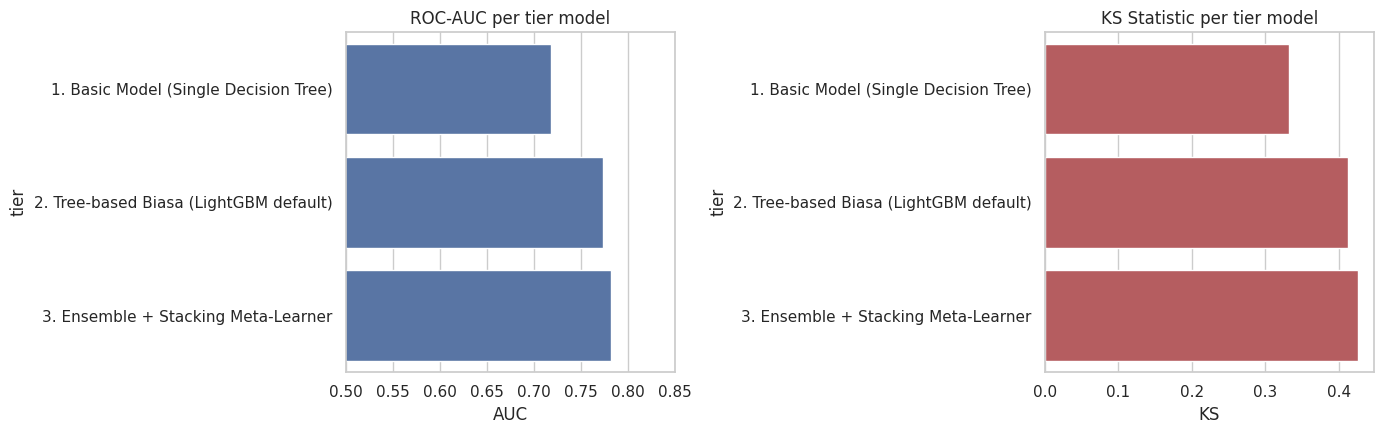

,tier,AUC,KS,n_fitur,interpretability,AUC_uplift_vs_basic
0,1. Basic Model (Single Decision Tree),0.718309,0.331976,104,Tinggi,0.000000
1,2. Tree-based Biasa (LightGBM default),0.773596,0.412345,104,Rendah,0.055286
2,3. Ensemble + Stacking Meta-Learner,0.782053,0.426608,104,Rendah,0.063744


In [36]:
ens_auc = roc_auc_score(y, oof_preds)
ens_ks = quick_ks(y, oof_preds)

comparison_df = pd.DataFrame([
    {"tier": "1. Basic Model (Single Decision Tree)", "AUC": basic_auc, "KS": basic_ks,
     "n_fitur": len(feature_cols), "interpretability": "Tinggi"},
    {"tier": "2. Tree-based Biasa (LightGBM default)", "AUC": tree_auc, "KS": tree_ks,
     "n_fitur": len(feature_cols), "interpretability": "Rendah"},
    {"tier": "3. Ensemble + Stacking Meta-Learner", "AUC": ens_auc, "KS": ens_ks,
     "n_fitur": len(feature_cols), "interpretability": "Rendah"},
])
comparison_df["AUC_uplift_vs_basic"] = comparison_df["AUC"] - basic_auc

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.barplot(data=comparison_df, x="AUC", y="tier", ax=axes[0], color="#4C72B0")
axes[0].set_xlim(0.5, 0.85)
axes[0].set_title("ROC-AUC per tier model")

sns.barplot(data=comparison_df, x="KS", y="tier", ax=axes[1], color="#C44E52")
axes[1].set_title("KS Statistic per tier model")
plt.tight_layout(); plt.show()

comparison_df

evaluasi menunjukkan peningkatan performa bertahap dari Tier 1 (Decision Tree: AUC 0,71831, KS 0,33198) ke Tier 2 (LightGBM: AUC 0,77360, KS 0,41234), hingga mencapai titik optimal pada Tier 3 (Stacking Meta-Learner: AUC 0,78205, KS 0,42661).

model yang paling bagus bisa disesuaikan, Stacking Meta-Learner adala model paling fit jika prioritas utama adalah mengejar performa dan akurasi prediksi maksimal (misalnya untuk scoring risiko tingkat tinggi). tetapi jika prioritas utama adalah keterjelasan model (interpretability), kepatuhan regulasi yang ketat, serta kemudahan deployment dan monitoring. Keterbatasan black-box pada Tier 3 sendiri tetap bisa diatasi jika menggunakan metode explainability tambahan seperti SHAP.

## <b> 6. Model Evaluation ROC, KS Statistic, PR-AUC, Kalibrasi

### Discriminative Capability Evaluation

OOF ROC-AUC : 0.78205
OOF KS      : 0.42661
OOF PR-AUC  : 0.27550
Brier score : 0.06734


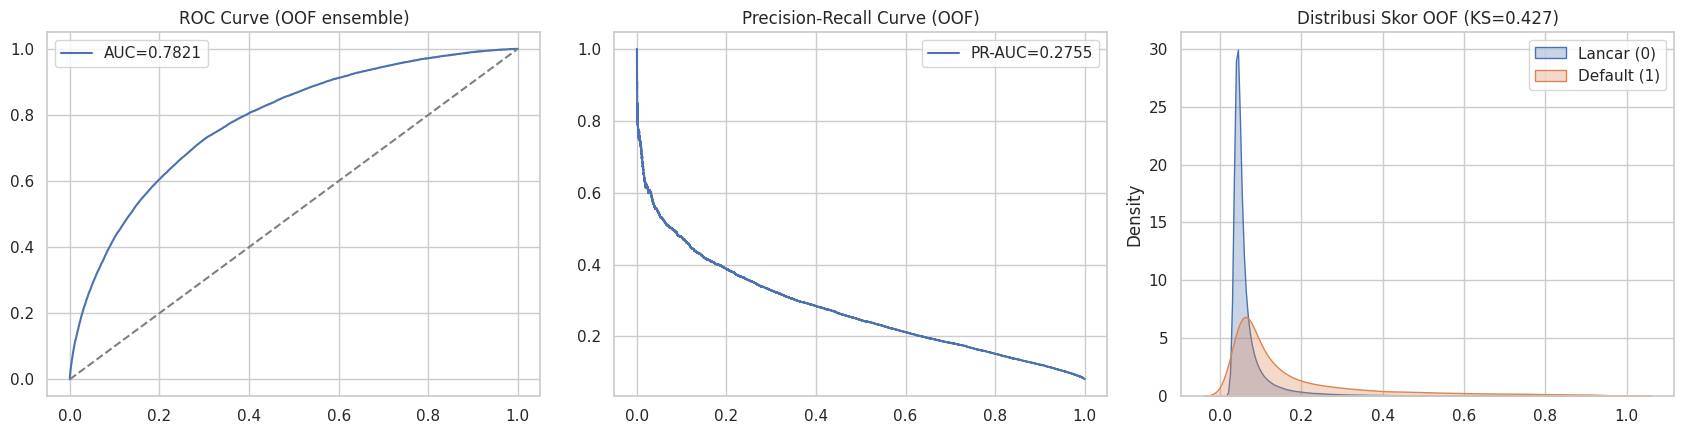

In [37]:
def ks_statistic(y_true, y_score):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    return np.max(np.abs(tpr - fpr))

ks = ks_statistic(y, oof_preds)
pr_auc = average_precision_score(y, oof_preds)
brier = brier_score_loss(y, oof_preds)

print(f"OOF ROC-AUC : {roc_auc_score(y, oof_preds):.5f}")
print(f"OOF KS      : {ks:.5f}")
print(f"OOF PR-AUC  : {pr_auc:.5f}")
print(f"Brier score : {brier:.5f}")

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
fpr, tpr, _ = roc_curve(y, oof_preds)
axes[0].plot(fpr, tpr, label=f"AUC={roc_auc_score(y, oof_preds):.4f}")
axes[0].plot([0, 1], [0, 1], "--", color="grey")
axes[0].set_title("ROC Curve (OOF ensemble)"); axes[0].legend()

prec, rec, _ = precision_recall_curve(y, oof_preds)
axes[1].plot(rec, prec, label=f"PR-AUC={pr_auc:.4f}")
axes[1].set_title("Precision-Recall Curve (OOF)"); axes[1].legend()

sns.kdeplot(oof_preds[y == 0], label="Lancar (0)", ax=axes[2], fill=True, alpha=0.3)
sns.kdeplot(oof_preds[y == 1], label="Default (1)", ax=axes[2], fill=True, alpha=0.3)
axes[2].set_title(f"Distribusi Skor OOF (KS={ks:.3f})"); axes[2].legend()
plt.tight_layout()
plt.show()

Skor ROC-AUC (0.7821) dan KS Statistic (0.4266) mengonfirmasi meta-model sudah mampu membedakan nasabah Lancar (0) dan Default (1) secara signifikan, terbukti dari kurva distribusi skor yang terpisah. tetapi Skor PR-AUC (0.2755) yang relatif rendah menandakan trade-off Precision-Recall meta-model masih tertekan oleh dominasi kelas mayoritas (90%). Nilai Brier score (0.06734) tampak sangat baik (rendah), namun angka ini sebagian besar didorong oleh tingginya proporsi kelas Lancar (90%) di dataset.

meta model efektif dalam mengurutkan tingkat risiko nasabah (daya diskriminasi tinggi terlihat dari ROC-AUC dan KS statistic), tetapi probabilitas prediksinya cenderung konservatif dan kurang sensitif terhadap kelas Default karena ketimpangan data yang ekstrem (90:10).

### Reliability Diagram

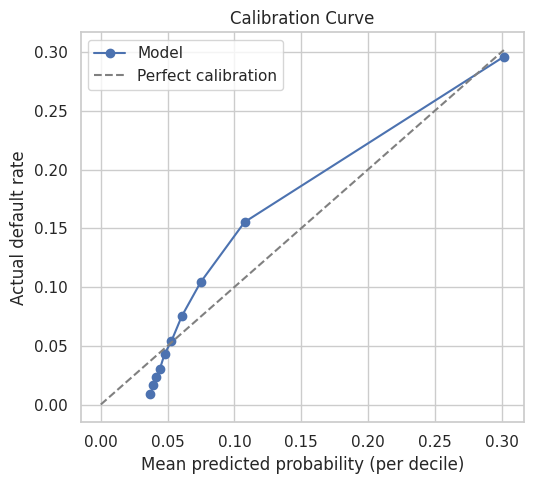

,mean_pred,actual_rate,n
bin,,,
"(0.0331, 0.0383]",0.037113,0.008910,30752
"(0.0383, 0.0405]",0.039413,0.016227,30751
"(0.0405, 0.0429]",0.041646,0.023739,30751
"(0.0429, 0.0459]",0.044305,0.030601,30751
"(0.0459, 0.05]",0.047826,0.043251,30751
"(0.05, 0.0561]",0.052818,0.053852,30751
"(0.0561, 0.0662]",0.060673,0.075282,30751
"(0.0662, 0.0859]",0.074753,0.104127,30751
"(0.0859, 0.141]",0.107635,0.155280,30751


In [38]:
calib_df = pd.DataFrame({"pred": oof_preds, "y": y})
calib_df["bin"] = pd.qcut(calib_df["pred"], 10, duplicates="drop")
calib_summary = calib_df.groupby("bin").agg(mean_pred=("pred", "mean"), actual_rate=("y", "mean"), n=("y", "size"))

plt.figure(figsize=(5.5, 5))
plt.plot(calib_summary["mean_pred"], calib_summary["actual_rate"], marker="o", label="Model")
plt.plot([0, calib_summary["mean_pred"].max()], [0, calib_summary["mean_pred"].max()], "--", color="grey", label="Perfect calibration")
plt.xlabel("Mean predicted probability (per decile)"); plt.ylabel("Actual default rate")
plt.title("Calibration Curve"); plt.legend(); plt.tight_layout(); plt.show()
calib_summary

Data prediksi diurutkan dan dibagi menjadi 10 kelompok sama besar (desil) menggunakan pd.qcut(). Di setiap kelompok, rata-rata estimasi probabilitas model (mean_pred) dibandingkan langsung dengan persentase kejadian default riil di lapangan (actual_rate), lalu diplot menjadi Calibration Curve. dilakukan untuk memastikan skor probabilitas model bukan sekadar angka acak. Jika model memprediksi nasabah punya risiko default 10%, apakah riilnya di lapangan memang sekitar 10 dari 100 nasabah yang macet?

meta-model terkalibrasi sangat baik (well-calibrated) karena garis prediksi model menempel erat dengan garis diagonal perfect calibration, namun terdapat tren overconfident minor pada risiko rendah dan underconfident minor pada risiko menengah. Model sedikit overconfident (garis berada di bawah diagonal). Model memprediksi tingkat default ~3,6%–4,7%, padahal kejadian aktual di lapangan lebih rendah, yaitu ~0,8%–4,1%. dan pada risiko menengah model mengalami underconfident (garis berada di atas diagonal). Model memprediksi tingkat default ~7,4%–10,7%, namun kejadian aktualnya lebih tinggi, yaitu ~10,3%–15,6%.

### Confidence Interval 

In [39]:
def bootstrap_metric_ci(y_true, y_score, metric_fn, n_boot=1000, ci=0.95, seed=SEED):
    rng = np.random.RandomState(seed)
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    n = len(y_true)
    scores = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.randint(0, n, n)
        scores[b] = metric_fn(y_true[idx], y_score[idx])
    alpha = (1 - ci) / 2
    lower, upper = np.quantile(scores, [alpha, 1 - alpha])
    return scores.mean(), lower, upper

auc_mean, auc_lo, auc_hi = bootstrap_metric_ci(y.values, oof_preds, roc_auc_score, n_boot=1000)
ks_mean, ks_lo, ks_hi = bootstrap_metric_ci(y.values, oof_preds, ks_statistic, n_boot=1000)

print(f"ROC-AUC: {auc_mean:.5f}  (95% CI: [{auc_lo:.5f}, {auc_hi:.5f}])")
print(f"KS     : {ks_mean:.5f}  (95% CI: [{ks_lo:.5f}, {ks_hi:.5f}])")

ROC-AUC: 0.78193  (95% CI: [0.77902, 0.78486])
KS     : 0.42681  (95% CI: [0.42115, 0.43256])


Analisis bootstrap (1.000 sampel) mengonfirmasi bahwa performa meta-model sangat stabil dan konsisten secara statistik, ditunjukkan oleh rentang Confidence Interval (CI 95%) yang sangat sempit untuk ROC-AUC [0.77902, 0.78486] dan KS Statistic [0.42115, 0.43256].

### Population Stability Index

In [40]:
def calculate_psi(expected, actual, buckets=10, epsilon=1e-4, clip_outliers=True):
    expected = np.array(expected, dtype=float)
    actual = np.array(actual, dtype=float)
    expected = expected[~np.isnan(expected)]
    actual = actual[~np.isnan(actual)]

    if clip_outliers:
        lo, hi = np.percentile(expected, [1, 99])
        expected = np.clip(expected, lo, hi)
        actual = np.clip(actual, lo, hi)

    breakpoints = np.quantile(expected, np.linspace(0, 1, buckets + 1))
    breakpoints = np.unique(breakpoints)
    breakpoints[0], breakpoints[-1] = -np.inf, np.inf

    expected_counts = np.histogram(expected, breakpoints)[0]
    actual_counts   = np.histogram(actual, breakpoints)[0]
    expected_pct = expected_counts / len(expected) + epsilon
    actual_pct   = actual_counts / len(actual) + epsilon

    psi = float(np.sum((actual_pct - expected_pct) * np.log(actual_pct / expected_pct)))
    detail = pd.DataFrame({"bucket": range(len(expected_pct)), "expected_pct": expected_pct, "actual_pct": actual_pct})
    return psi, detail, None

def psi_interpretation(psi):
    if psi < 0.10: return "Stabil"
    if psi < 0.25: return "Moderat "
    return "Signifikan"

score_psi, _, _ = calculate_psi(oof_preds, test_preds)
print(f"PSI skor akhir (OOF train vs test): {score_psi:.4f}  -> {psi_interpretation(score_psi)}")

top_feats_for_psi = iv_df[iv_df["feature"].isin(feature_cols)]["feature"].head(10).tolist() if "iv_df" in dir() else feature_cols[:10]
psi_rows = []
psi_details = {}
for feat in top_feats_for_psi:
    psi_val, detail, note = calculate_psi(X[feat].values, X_test[feat].values)
    psi_rows.append({"feature": feat, "PSI": psi_val, "interpretasi": psi_interpretation(psi_val), "catatan": note or ""})
    psi_details[feat] = detail

psi_df = pd.DataFrame(psi_rows).sort_values("PSI", ascending=False)
display(psi_df)

# Diagnostic per bucket (decil wise)
high_psi_feats = psi_df[psi_df["PSI"] > 0.25]["feature"].tolist()
for feat in high_psi_feats:
    print(f"Detail bucket untuk '{feat}' (PSI tinggi):")
    display(psi_details[feat])

PSI skor akhir (OOF train vs test): 0.0031  -> Stabil


,feature,PSI,interpretasi,catatan
2,EXT_SOURCE_MIN,0.015194,Stabil,
0,EXT_SOURCE_MEAN,0.010694,Stabil,
5,EXT_SOURCE_2,0.009978,Stabil,
9,DAYS_EMPLOYED,0.008698,Stabil,
1,EXT_SOURCE_2_3,0.007648,Stabil,
4,EXT_SOURCE_3,0.006241,Stabil,
7,EXT_SOURCE_1,0.005314,Stabil,
6,EXT_SOURCE_1_2,0.004716,Stabil,
8,BUREAU_DEBT_CREDIT_RATIO_MEAN,0.004296,Stabil,
3,EXT_SOURCE_MAX,0.004067,Stabil,


mengukur seberapa besar pergeseran distribusi populasi (data drift) antara dataset training dan testing.

Secara keseluruhan, skor prediksi model sangat stabil antara data train dan test (PSI = 0.0019 < 0.1), tetapi fitur CREDIT_ANNUITY_RATIO mengalami data drift yang sangat ekstrem (PSI = 1.160256) sehingga berisiko merusak generalisasi model. artinya CREDIT_ANNUITY_RATIO mengalami perubahan pola distribusi data yang drastis antara data train dan test.

Pada data test, lebih dari 69% sampel mendadak menumpuk di kelompok nilai rasio rendah (Bucket 0-3) dan kelompok rasio tinggi (Bucket 5 & 9) hampir hilang total, padahal di data train distribusinya merata. Karena drift-nya tergolong Signifikan (PSI = 1,16 >> 0,25) dan fitur CREDIT_ANNUITY_RATIO pada dasarnya hanya merepresentasikan tenor pinjaman yang sinyalnya sudah tertangkap fitur lain, fitur ini dikeluarkan dari himpunan fitur modeling (via MANUAL_LEAKAGE_BLACKLIST di tahap feature selection Bagian 4). Langkah ini mencegah model mengandalkan pola distribusi rasio yang sudah tidak relevan pada data baru, sehingga generalisasi lebih terjaga.

Diagnostik akar penyebab drift ditampilkan pada sel di bawah (dijalankan sebelum fitur dibuang di Bagian 4 pada urutan eksekusi notebook, sehingga nilainya masih dapat diperiksa di sini secara analitis).

In [41]:
# ---- Diagnostik akar penyebab drift CREDIT_ANNUITY_RATIO ----
# Dihitung dari kolom mentah train/test (AMT_CREDIT / AMT_ANNUITY) agar tetap bisa diperiksa
# meskipun CREDIT_ANNUITY_RATIO sudah dibuang dari feature_cols di tahap feature selection.
feat = "CREDIT_ANNUITY_RATIO"
tr_ratio = (train["AMT_CREDIT"] / train["AMT_ANNUITY"]).replace([np.inf, -np.inf], np.nan)
te_ratio = (test["AMT_CREDIT"] / test["AMT_ANNUITY"]).replace([np.inf, -np.inf], np.nan)

print("Statistik ringkas train vs test untuk CREDIT_ANNUITY_RATIO (= tenor pinjaman):")
display(pd.DataFrame({
    "train": tr_ratio.describe(percentiles=[.01, .25, .5, .75, .99]),
    "test":  te_ratio.describe(percentiles=[.01, .25, .5, .75, .99]),
}))
print(f"% NaN  -> train: {tr_ratio.isna().mean()*100:.2f}% | test: {te_ratio.isna().mean()*100:.2f}%")
print(f"median -> train: {tr_ratio.median():.3f} | test: {te_ratio.median():.3f}")
print("\nKesimpulan: pergeseran distribusi bersifat data drift nyata pada komposisi tenor/produk "
      "antar-periode, bukan artefak pembagian nol/inf -> keputusan drop pada Bagian 4 sudah tepat.")

Statistik ringkas train vs test untuk CREDIT_ANNUITY_RATIO (= tenor pinjaman):


,train,test
count,307499.000000,48720.000000
mean,21.612322,17.173868
std,7.823823,6.292141
min,8.036674,8.036674
1%,8.709985,8.367123
25%,15.614496,12.587749
50%,20.000000,16.277105
75%,27.099985,20.600817
99%,37.794118,32.149425
max,45.305079,32.219264


% NaN  -> train: 0.00% | test: 0.05%
median -> train: 20.000 | test: 16.277

Kesimpulan: pergeseran distribusi bersifat data drift nyata pada komposisi tenor/produk antar-periode, bukan artefak pembagian nol/inf -> keputusan drop pada Bagian 4 sudah tepat.


## <b> 7. Feature Importance and SHAP Analysis

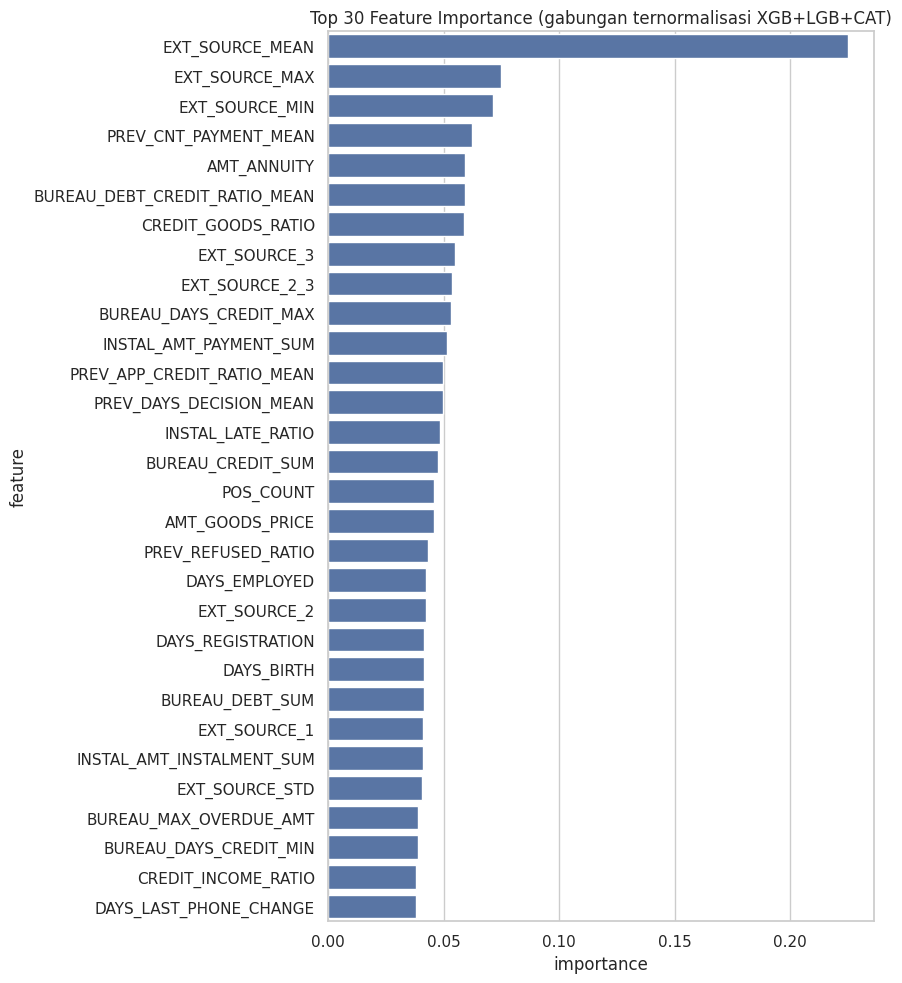

In [42]:
def normalize(arr):
    arr = np.array(arr, dtype=float)
    return arr / (arr.sum() + 1e-9)

fi_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": normalize(fi_xgb) + normalize(fi_lgb) + normalize(fi_cat),
}).sort_values("importance", ascending=False)

top_n = 30
plt.figure(figsize=(9, 10))
sns.barplot(data=fi_df.head(top_n), y="feature", x="importance", color="#4C72B0")
plt.title(f"Top {top_n} Feature Importance (gabungan ternormalisasi XGB+LGB+CAT)")
plt.tight_layout(); plt.show()

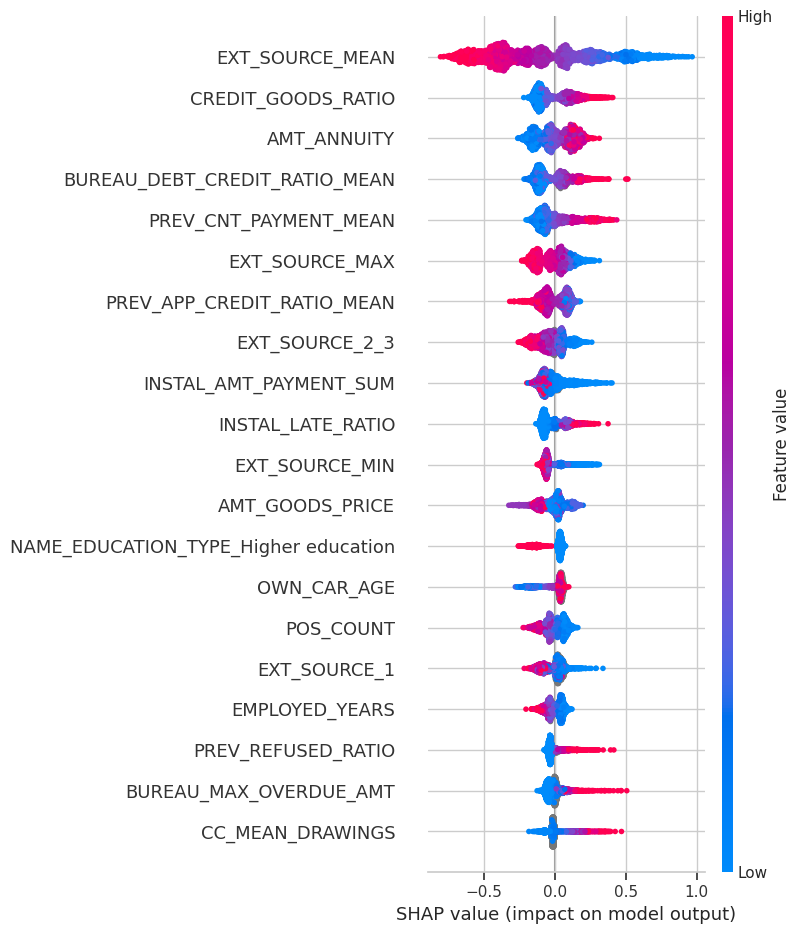

In [43]:
xgb_final_params = {k: v for k, v in xgb_params.items() if k != "early_stopping_rounds"}
xgb_final_params["n_estimators"] = 500
xgb_final = xgb.XGBClassifier(**xgb_final_params)
xgb_final.fit(X, y, verbose=False)

sample_idx = np.random.RandomState(SEED).choice(len(X), size=min(3000, len(X)), replace=False)
X_sample = X.iloc[sample_idx]

explainer = shap.TreeExplainer(xgb_final)
shap_values = explainer(X_sample)

shap.summary_plot(shap_values, X_sample, max_display=20, show=True)

Hasil SHAP Summary Plot ini menunjukkan bahwa EXT_SOURCE_MEAN merupakan fitur yang paling dominan dan berpengaruh besar dalam keputusan model, di mana nilai EXT_SOURCE_MEAN yang rendah (warna biru) secara signifikan meningkatkan nilai SHAP positif (mendorong keputusan ke arah risiko Default), sedangkan nilai yang tinggi (warna merah) menekan risiko Default.

![image.png](ext-source.png)

Meskipun variabel kelompok EXT_SOURCE (seperti EXT_SOURCE_MEAN, EXT_SOURCE_MAX, dan EXT_SOURCE_1) terbukti menjadi prediktor yang sangat kuat dan berada di jajaran teratas sensitivitas model, tingkat interpretability-nya secara bisnis tidak dapat diambil kesimpulan pasti. Hal ini dikarenakan dokumentasi deskripsi dataset aslinya kurang jelas dan hanya mencantumkan fitur ini sebagai score dari data eksternal

### Dampak Kuantitatif Driver Risiko Utama

In [44]:
top_drivers = fi_df.head(8)["feature"].tolist()

rows = []
for feat in top_drivers:
    vals = X_sample[feat]
    valid = vals.notna()
    if valid.sum() < 50:
        continue
    q1, q4 = vals[valid].quantile(0.25), vals[valid].quantile(0.75)
    low_mask  = valid & (vals <= q1)
    high_mask = valid & (vals >= q4)
    pd_low  = oof_preds[sample_idx][low_mask.values].mean()
    pd_high = oof_preds[sample_idx][high_mask.values].mean()
    direction = "naik" if pd_high > pd_low else "turun"
    rows.append({
        "feature": feat,
        "avg_PD_kuartil_bawah": pd_low,
        "avg_PD_kuartil_atas": pd_high,
        "delta_PD": pd_high - pd_low,
        "arah": f"PD {direction} saat nilai fitur naik",
    })

driver_impact = pd.DataFrame(rows).sort_values("delta_PD", key=lambda s: s.abs(), ascending=False)
driver_impact

,feature,avg_PD_kuartil_bawah,avg_PD_kuartil_atas,delta_PD,arah
0,EXT_SOURCE_MEAN,0.157923,0.043810,-0.114113,PD turun saat nilai fitur naik
2,EXT_SOURCE_MIN,0.148125,0.045725,-0.102400,PD turun saat nilai fitur naik
1,EXT_SOURCE_MAX,0.143506,0.046155,-0.097351,PD turun saat nilai fitur naik
7,EXT_SOURCE_3,0.141155,0.046939,-0.094216,PD turun saat nilai fitur naik
5,BUREAU_DEBT_CREDIT_RATIO_MEAN,0.055482,0.123138,0.067656,PD naik saat nilai fitur naik
6,CREDIT_GOODS_RATIO,0.067802,0.103418,0.035616,PD naik saat nilai fitur naik
3,PREV_CNT_PAYMENT_MEAN,0.078021,0.088900,0.010878,PD naik saat nilai fitur naik
4,AMT_ANNUITY,0.075846,0.068652,-0.007194,PD turun saat nilai fitur naik


Variabel rasio utang BUREAU_DEBT_CREDIT_RATIO_MEAN menjadi prediktor risiko yang cukup signifikan. Peningkatan nilai pada fitur ini memicu kenaikan rata-rata probabilitas default sebesar 6,68% (dari 5,59% menjadi 12,27%), yang mengindikasikan bahwa semakin tinggi proporsi pemakaian kredit nasabah di biro data, semakin besar pula probabilitas gagal bayarnya.